# 4.2 Demand Prediction

In this notebook we implement Neural Networks (NNs) to predict taxi trip demand in chicago. Additionally, we compare the performances of the NNs across different complexity levels.

For NNs there are 2 "main" complexity interpretations:
- depth: number of hidden layers
- width: number of nodes per layer
- (more complex activation function) - maybe as an extra
- (more complex optimizer) - maybe as an extra

So we decide to test 3 different NN structures:

__baseline model__:
- hidden layers: 2
- nodes per layer: 64

__wider model__:
- hidden layers: 2
- nodes per layer: 256

__deeper model__:
- hidden layers: 8
- nodes per layer: 64

For better comparison, we will test all three architectures with the same shared configurations.

Before training any NN, we establish two simple **benchmarks** to contextualise the results:

1. **Historical-mean predictor** — for each hexagon × hour-of-day pair, predict the mean `trip_count` seen in the training set. Unseen combinations fall back to the global training mean. This captures the dominant demand pattern (location + time-of-day) without any learning.
2. **Ridge regression** — a linear model fit on the same scaled feature matrix. Trained on log₁⁺ demand and back-transformed at evaluation time (same target encoding as the NNs). This shows how much a linear model can do before adding any non-linearity or depth.

## Table of Contents

- [4.2.1 Data Information](#421-data-information)
- [4.2.2 Model Configurations](#422-model-configurations)
- [4.2.3 Model Definition](#423-model-definition)
- [4.2.4 Hyperparameter Search Definition (GridSearch)](#424-hyperparameter-search-definition-gridsearch)
- [4.2.5 Visualization: Model Architecture](#425-visualization-model-architecture)
- [4.2.6 Train / Val / Test Split](#426-train--val--test-split)
- [4.2.7 Feature Preparation](#427-feature-preparation)
- [4.2.8 Benchmark Models](#428-benchmark-models)
- [4.2.9 Baseline Model — Training](#429-baseline-model--training)
  - [4.2.9 Baseline Model — Evaluation](#429-baseline-model--evaluation)
- [4.2.10 Hyperparameter Search — Baseline Model](#4210-hyperparameter-search--baseline-model)
  - [4.2.10 Tuned Baseline — Training](#4210-tuned-baseline--training)
  - [4.2.10 Tuned Baseline — Evaluation](#4210-tuned-baseline--evaluation)
- [4.2.11 Deeper Model — Training](#4211-deeper-model--training)
  - [4.2.11 Deeper Model — Evaluation](#4211-deeper-model--evaluation)
- [4.2.12 Hyperparameter Search — Deeper Model](#4212-hyperparameter-search--deeper-model)
  - [4.2.12 Wider Model — Training](#4212-wider-model--training)
  - [4.2.12 Wider Model — Evaluation](#4212-wider-model--evaluation)
  - [4.2.12 Hyperparameter Search — Wider Model](#4212-hyperparameter-search--wider-model)
  - [4.2.12 Tuned Wider — Training](#4212-tuned-wider--training)
  - [4.2.12 Tuned Wider — Evaluation](#4212-tuned-wider--evaluation)

In [41]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Import packages                         #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

import pandas as pd
# import matplotlib.pyplot as plt

# modeling
import copy
import random
import types
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score as _r2

# evaluation
import datetime
from tqdm.auto import tqdm as _tqdm

# visualization
from torchinfo import summary
import matplotlib.pyplot as plt

# reset working dir
import os
from pathlib import Path


In [42]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Reset working directory                 #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

import __main__
_nb = getattr(__main__, "__vsc_ipynb_file__", None) or os.environ.get("JPY_SESSION_NAME")
_start = Path(_nb).resolve().parent if _nb else Path.cwd()
os.chdir(next(p for p in [_start, *_start.parents] if (p / "pyproject.toml").exists()))
print(f"Working directory: {os.getcwd()}")

Working directory: /Users/anthony/Documents/Dokumente – MacBook Pro von Anthony/UNI/AAA/AAA_TA_2026


In [43]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Load data                               #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

data = pd.read_parquet("data/aggregated/hexagon/demand_hex_6h_low.parquet")

In [44]:
data

,time_bucket,bucket_index,pickup_h3_res6,area_type,trip_count,active_taxis,avg_idle_time,avg_trip_duration,avg_trip_distance,avg_fare,...,dist_to_nearest_train_station_km,dist_to_nearest_stadium_km,train_station_per_km2,restaurants_per_km2,bars_and_clubs_per_km2,hotels_per_km2,hospitals_per_km2,universities_per_km2,attractions_per_km2,poi_density_total_per_km2
0,2025-01-01 00:00:00,482136,862664197ffffff,residential,1,1,15.000000,818.000000,14.540000,35.750000,...,3.463863,5.190882,0.000000,0.412471,0.219985,0.000000,0.000000,0.000000,0.027498,0.659954
1,2025-01-01 00:00:00,482136,86266419fffffff,residential,0,0,0.000000,0.000000,0.000000,0.000000,...,0.770790,5.836479,0.055042,0.137605,0.055042,0.055042,0.000000,0.000000,0.027521,0.330253
2,2025-01-01 00:00:00,482136,8626641b7ffffff,residential,0,0,0.000000,0.000000,0.000000,0.000000,...,3.428506,4.626667,0.027470,0.247232,0.027470,0.000000,0.000000,0.000000,0.000000,0.302173
3,2025-01-01 00:00:00,482136,862664527ffffff,airport,5,5,0.000000,1676.000000,12.868000,33.700000,...,2.529989,4.162891,0.027462,0.631634,0.302086,0.000000,0.000000,0.000000,0.000000,0.961182
4,2025-01-01 00:00:00,482136,86266452fffffff,residential,0,0,0.000000,0.000000,0.000000,0.000000,...,2.695998,5.548927,0.054970,0.659643,0.137426,0.384792,0.054970,0.027485,0.027485,1.346772
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48175,2025-12-31 18:00:00,490890,862664dafffffff,residential,2,2,30.000000,1146.000000,4.780000,15.565000,...,3.960234,4.291273,0.000000,0.027329,0.000000,0.000000,0.000000,0.000000,0.000000,0.027329
48176,2025-12-31 18:00:00,490890,862759347ffffff,airport,199,186,131.351351,2061.010050,14.953568,39.344925,...,2.892475,2.057285,0.136860,1.176998,0.301092,0.520069,0.000000,0.000000,0.027372,2.162392
48177,2025-12-31 18:00:00,490890,86275934fffffff,airport,219,191,129.179104,1946.347032,14.084886,37.325342,...,1.220338,2.809967,0.191761,1.068385,0.465706,0.383523,0.000000,0.000000,0.027394,2.136770
48178,2025-12-31 18:00:00,490890,86275935fffffff,airport,67,67,145.125000,2002.208955,14.049701,36.960896,...,1.340206,7.539746,0.054799,0.273996,0.054799,0.027400,0.000000,0.000000,0.000000,0.410994


## 4.2.1 Data Information

In [45]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Data Information                        #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

# How many times does each row repeat when ignoring the time bucket?
# bucket_index is also excluded as it is a numeric encoding of the time bucket.
cols_no_time = [c for c in data.columns if c not in ('time_bucket', 'bucket_index')]
counts = data[cols_no_time].value_counts()

n_total    = len(data)
n_unique   = len(counts)
n_repeated = int((counts > 1).sum())

print(f"Total rows                    : {n_total:>10,}")
print(f"Unique combinations (no time) : {n_unique:>10,}")
print(f"Combinations appearing >1x    : {n_repeated:>10,}")
print(f"Avg repetitions per combo     : {n_total / n_unique:>10.2f}x")
print(f"\nRepetition count distribution:")
dist = counts.value_counts().sort_index()
for k, v in dist.items():
    print(f"  appears {k:>3}x : {v:>8,} combinations")

# How often does each hexagon + hour-of-day combination appear?
hex_hour_counts = data.groupby(['pickup_h3_res6', 'hour_of_day']).size()

print(f"\n--- Hexagon × Hour-of-day ---")
print(f"Unique hex × hour combinations : {len(hex_hour_counts):>8,}")
print(f"Avg appearances per combo      : {hex_hour_counts.mean():>8.1f}x")
print(f"Min appearances                : {hex_hour_counts.min():>8,}")
print(f"Max appearances                : {hex_hour_counts.max():>8,}")

# Zero-demand rows
n_zero        = int((data['trip_count'] == 0).sum())
pct_zero      = 100.0 * n_zero / n_total
print(f"\n--- Demand ---")
print(f"Zero-demand rows               : {n_zero:>8,}  ({pct_zero:.1f}%)")
print(f"Non-zero-demand rows           : {n_total - n_zero:>8,}  ({100 - pct_zero:.1f}%)")

Total rows                    :     48,180
Unique combinations (no time) :     48,180
Combinations appearing >1x    :          0
Avg repetitions per combo     :       1.00x

Repetition count distribution:
  appears   1x :   48,180 combinations

--- Hexagon × Hour-of-day ---
Unique hex × hour combinations :      132
Avg appearances per combo      :    365.0x
Min appearances                :      365
Max appearances                :      365

--- Demand ---
Zero-demand rows               :    6,956  (14.4%)
Non-zero-demand rows           :   41,224  (85.6%)


In [46]:
data.head()

,time_bucket,bucket_index,pickup_h3_res6,area_type,trip_count,active_taxis,avg_idle_time,avg_trip_duration,avg_trip_distance,avg_fare,...,dist_to_nearest_train_station_km,dist_to_nearest_stadium_km,train_station_per_km2,restaurants_per_km2,bars_and_clubs_per_km2,hotels_per_km2,hospitals_per_km2,universities_per_km2,attractions_per_km2,poi_density_total_per_km2
0,2025-01-01,482136,862664197ffffff,residential,1,1,15.0,818.0,14.540,35.75,...,3.463863,5.190882,0.000000,0.412471,0.219985,0.000000,0.00000,0.000000,0.027498,0.659954
1,2025-01-01,482136,86266419fffffff,residential,0,0,0.0,0.0,0.000,0.00,...,0.770790,5.836479,0.055042,0.137605,0.055042,0.055042,0.00000,0.000000,0.027521,0.330253
2,2025-01-01,482136,8626641b7ffffff,residential,0,0,0.0,0.0,0.000,0.00,...,3.428506,4.626667,0.027470,0.247232,0.027470,0.000000,0.00000,0.000000,0.000000,0.302173
3,2025-01-01,482136,862664527ffffff,airport,5,5,0.0,1676.0,12.868,33.70,...,2.529989,4.162891,0.027462,0.631634,0.302086,0.000000,0.00000,0.000000,0.000000,0.961182
4,2025-01-01,482136,86266452fffffff,residential,0,0,0.0,0.0,0.000,0.00,...,2.695998,5.548927,0.054970,0.659643,0.137426,0.384792,0.05497,0.027485,0.027485,1.346772


## 4.2.2 Model Configurations

In [47]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Shared Configs                          #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

# --- optimization ---
OPTIMIZER          = "adam"
LEARNING_RATE      = 5e-5
WEIGHT_DECAY       = 0.0     # decoupled L2 (AdamW); per-arch values come from the HP search
BATCH_SIZE         = 1024
MAX_EPOCHS         = 200

# --- loss / output ---
LOSS               = "nb_nll"  # "mse" | "mae" | "poisson_nll" | "nb_nll" (count NLLs: raw-count targets, log-rate output)
OUTPUT_UNITS       = 1
OUTPUT_ACTIVATION  = "softplus"

# --- layer defaults ---
HIDDEN_ACTIVATION  = "relu"
WEIGHT_INIT        = "he_normal"

# --- early stopping ---
EARLY_STOPPING     = True
MONITOR            = "val_loss"
PATIENCE           = 10

# --- data handling ---
SPLIT              = "random"
SCALER_FIT_ON      = "train_only"

# --- hex embedding ---
HEX_EMBED_DIM      = 16      # learned embedding dim per hexagon

# --- device ---
device = "cuda" if torch.cuda.is_available() else "cpu"

# --- reproducibility ---
SEEDS              = (0,)

# --- architectures ---
ARCH_BASELINE      = (2, 64)
ARCH_WIDER         = (2, 256)
ARCH_DEEPER        = (8, 64)

config = types.SimpleNamespace(
    LOSS           = LOSS,
    OPTIMIZER      = OPTIMIZER,
    LEARNING_RATE  = LEARNING_RATE,
    WEIGHT_DECAY   = WEIGHT_DECAY,
    BATCH_SIZE     = BATCH_SIZE,
    MAX_EPOCHS     = MAX_EPOCHS,
    EARLY_STOPPING = EARLY_STOPPING,
    PATIENCE       = PATIENCE,
    OUTPUT_UNITS   = OUTPUT_UNITS,
    HEX_EMBED_DIM  = HEX_EMBED_DIM,
)

ARCH_NAMES = {ARCH_BASELINE: "baseline", ARCH_WIDER: "wide", ARCH_DEEPER: "deep"}

HP_SEARCH_SEEDS        = (0,)
HP_PATIENCE            = 10
BEST_HP                = {}

HP_LR_CANDIDATES = []
HP_WD_CANDIDATES = [0.0]


## 4.2.3 Model Definition

In [48]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Model + Training Utilities              #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

def nb_nll_loss(log_mu, y, log_theta):
    """NB2 negative log-likelihood: mean μ = exp(log_mu), Var = μ + μ²/θ, θ = exp(log_theta)."""
    theta   = torch.exp(log_theta)
    mu      = torch.exp(log_mu)
    log_t_m = torch.log(theta + mu)
    ll = (torch.lgamma(y + theta) - torch.lgamma(theta) - torch.lgamma(y + 1.0)
          + theta * (log_theta - log_t_m)
          + y     * (log_mu    - log_t_m))
    return -ll.mean()


class DemandBaseline(nn.Module):
    def __init__(self, input_dim, n_layers, width, n_hex, embed_dim):
        super().__init__()
        self.hex_embed = nn.Embedding(n_hex, embed_dim)
        nn.init.normal_(self.hex_embed.weight, std=0.01)

        layers = []
        in_dim = input_dim + embed_dim
        for _ in range(n_layers):
            linear = nn.Linear(in_dim, width)
            nn.init.kaiming_normal_(linear.weight, nonlinearity="relu")
            nn.init.zeros_(linear.bias)
            layers += [linear, nn.ReLU()]
            in_dim = width
        out = nn.Linear(in_dim, config.OUTPUT_UNITS)
        nn.init.kaiming_normal_(out.weight, nonlinearity="relu")
        nn.init.zeros_(out.bias)
        layers.append(out)
        if getattr(config, "LOSS", "mse") not in ("poisson_nll", "nb_nll"):
            layers.append(nn.Softplus())   # output = log1p(y) estimate
        # else: output = unconstrained log-rate log(μ), consumed by the Poisson/NB NLL
        self.net = nn.Sequential(*layers)

        if getattr(config, "LOSS", "mse") == "nb_nll":
            # NB2 dispersion, trained jointly with the network weights
            self.log_theta = nn.Parameter(torch.zeros(()))

    def forward(self, x, hex_idx):
        emb = self.hex_embed(hex_idx)          # (batch, embed_dim)
        x   = torch.cat([x, emb], dim=-1)      # (batch, input_dim + embed_dim)
        return self.net(x).squeeze(-1)


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def train_model(arch, X_train, y_train, X_val, y_val,
                hex_train, hex_val,
                seed=0, device="cpu", verbose=True, lr=None,
                batch_size=None, patience=None, weight_decay=None,
                embed_dim=None):
    set_seed(seed)
    n_layers, width = arch
    _embed_dim  = embed_dim  if embed_dim  is not None else config.HEX_EMBED_DIM
    _batch_size = batch_size if batch_size is not None else config.BATCH_SIZE
    _patience   = patience   if patience   is not None else config.PATIENCE
    model = DemandBaseline(X_train.shape[1], n_layers, width, N_HEX, _embed_dim).to(device)

    _loss_name = getattr(config, "LOSS", "mse")
    if _loss_name == "mse":
        loss_fn = nn.MSELoss()
    elif _loss_name == "mae":
        loss_fn = nn.L1Loss()
    elif _loss_name == "poisson_nll":
        loss_fn = nn.PoissonNLLLoss(log_input=True, full=False)   # model outputs log-rate; exp() applied internally
    elif _loss_name == "nb_nll":
        def loss_fn(log_mu, y):   # model outputs log-mean; dispersion θ trained jointly
            return nb_nll_loss(log_mu, y, model.log_theta)
    else:
        raise ValueError(f"unknown config.LOSS: {_loss_name!r}")

    _lr             = lr if lr is not None else config.LEARNING_RATE
    _wd             = weight_decay if weight_decay is not None else getattr(config, 'WEIGHT_DECAY', 0.0)
    _optimizer_name = getattr(config, 'OPTIMIZER', 'adam').lower()
    if _optimizer_name == 'sgd':
        optimizer = torch.optim.SGD(model.parameters(), lr=_lr, momentum=0.9, weight_decay=_wd)
    elif _optimizer_name == 'rmsprop':
        optimizer = torch.optim.RMSprop(model.parameters(), lr=_lr, weight_decay=_wd)
    else:
        # AdamW = decoupled weight decay; plain Adam's L2 gets rescaled by the adaptive LR
        optimizer = torch.optim.AdamW(model.parameters(), lr=_lr, weight_decay=_wd)

    train_dl = DataLoader(
        TensorDataset(
            torch.as_tensor(X_train,   dtype=torch.float32),
            torch.as_tensor(hex_train, dtype=torch.long),
            torch.as_tensor(y_train,   dtype=torch.float32),
        ),
        batch_size=_batch_size,
        shuffle=True,
    )
    X_val_t   = torch.as_tensor(X_val,   dtype=torch.float32).to(device)
    hex_val_t = torch.as_tensor(hex_val, dtype=torch.long).to(device)
    y_val_t   = torch.as_tensor(y_val,   dtype=torch.float32).to(device)

    best_val, best_state, wait = float("inf"), None, 0
    best_train_loss = float("inf")
    ep_width        = len(str(config.MAX_EPOCHS))

    for epoch in range(config.MAX_EPOCHS):
        if verbose:
            print(f"Epoch {epoch + 1:{ep_width}d}/{config.MAX_EPOCHS}")

        model.train()
        running_loss, n_batches = 0.0, 0
        pbar = _tqdm(train_dl, leave=True, unit="step", disable=not verbose)
        for xb, hb, yb in pbar:
            xb, hb, yb = xb.to(device), hb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = loss_fn(model(xb, hb), yb)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            n_batches    += 1
            pbar.set_postfix({"loss": f"{running_loss / n_batches:.4f}"})
        train_loss = running_loss / n_batches

        model.eval()
        with torch.no_grad():
            val_loss = loss_fn(model(X_val_t, hex_val_t), y_val_t).item()

        if not np.isfinite(val_loss):
            if verbose:
                print(f"  ↳ diverged (val_loss={val_loss}) at epoch {epoch + 1}")
            break

        improved = val_loss < best_val
        if improved:
            best_val, best_state, wait = val_loss, copy.deepcopy(model.state_dict()), 0
            best_train_loss = train_loss
        else:
            wait += 1

        marker = " ✓" if improved else f"  (no improvement {wait}/{_patience})"
        pbar.set_postfix({"loss": f"{train_loss:.4f}", "val_loss": f"{val_loss:.4f}"})
        pbar.close()
        if verbose:
            print(f"  loss: {train_loss:.4f}  val_loss: {val_loss:.4f}{marker}")

        if config.EARLY_STOPPING and wait >= _patience:
            if verbose:
                print(f"\n  ↳ early stop at epoch {epoch + 1}"
                      f"  best_val={best_val:.4f}  best_train={best_train_loss:.4f}")
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    # else: run diverged before any improvement; best_val stays inf so the
    # HP search ranks the combo last instead of crashing
    return model, best_val, best_train_loss


## 4.2.4 Hyperparameter Search Definition (GridSearch)

In [49]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# HP Search Utility                       #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

def run_hp_search(arch, X_train, y_train, X_val, y_val,
                  hex_train, hex_val,
                  device='cpu',
                  lr_candidates=None, wd_candidates=None, seeds=None):
    import itertools

    lr_candidates = lr_candidates or HP_LR_CANDIDATES
    wd_candidates = wd_candidates if wd_candidates is not None else HP_WD_CANDIDATES
    seeds         = seeds         or HP_SEARCH_SEEDS
    arch_label    = ARCH_NAMES.get(arch, str(arch))

    combos = list(itertools.product(lr_candidates, wd_candidates))

    print(f'HP Search — {arch_label}')
    print(f'{len(combos)} combos × {len(seeds)} seed(s)'
          f' = {len(combos) * len(seeds)} runs  |  patience={HP_PATIENCE}\n')
    print(f"{'#':>4}  {'lr':>8}  {'wd':>8}  {'mean val':>10}  {'std':>8}")
    print('-' * 45)

    results = []
    for i, (lr, wd) in enumerate(combos, 1):
        val_losses = []
        for seed in seeds:
            _, val_loss, _ = train_model(
                arch, X_train, y_train, X_val, y_val,
                hex_train, hex_val,
                seed=seed, device=device, verbose=False,
                lr=lr, weight_decay=wd, patience=HP_PATIENCE,
            )
            val_losses.append(val_loss)
        mean_loss = float(np.mean(val_losses))
        std_loss  = float(np.std(val_losses))
        results.append({
            'lr': lr, 'weight_decay': wd,
            'mean_val_loss': mean_loss, 'std_val_loss': std_loss,
        })
        print(f'{i:>4}  {lr:>8.0e}  {wd:>8.0e}  {mean_loss:>10.4f}  {std_loss:>8.4f}')

    results_df = pd.DataFrame(results).sort_values('mean_val_loss').reset_index(drop=True)
    print(f'\n--- Top 5 ---')
    print(results_df.head(5).to_string(index=False))

    best = results_df.iloc[0]
    BEST_HP[arch] = {'lr': float(best['lr']), 'weight_decay': float(best['weight_decay'])}
    print(f'\nBEST_HP[{arch_label}] = {BEST_HP[arch]}')
    return BEST_HP[arch]


## 4.2.5 Visualization: Model Architecture

```
One row of raw data
┌─────────────────┬──────────────────────────────┬─────────────┐
│ pickup_h3_res6  │  is_weekend, temp, rain, ...  │ trip_count  │
│ '862664197ffffff' │  0,  12.3,  0.0,  ...      │      5      │
└────────┬────────┴───────────────┬───────────────┴──────┬──────┘
         │                       │                       │
         ▼                       ▼                       ▼
    hex_vocab              StandardScaler             target y
  '862664197ffffff'       [0.0, -0.3, ...]              5.0
       → 42
         │                       │
         ▼                       │
  Embedding table                │
  (N_HEX hexagons × 16 dims)     │
  row 42: [0.12, -0.31, ...]     │
     (16 dims, learned)          │ (n_num dims, scaled)
         │                       │
         └───────────┬───────────┘
                     ▼
               torch.cat(...)
          [0.12, -0.31, ..., 0.0, -0.3, ...]
              (16 + n_num total dims)
                     │
                     ▼
           ┌─────────────────────┐
           │  Linear(dim → 64)   │
           │  ReLU               │
           │  Linear(64 → 64)    │  ← baseline / deeper adds more blocks
           │  ReLU               │
           │  Linear(64 → 1)     │
           │  Softplus           │  ← keeps output ≥ 0 (trip count)
           └─────────────────────┘
                     │
                     ▼
              ŷ  (predicted trip count)
```

The embedding table starts with near-zero weights and is updated by backprop
alongside all other parameters — the network learns which hexagons are similar.


## 4.2.6 Train / Val / Test Split

We split rows randomly into **70 % train / 15 % val / 15 % test** using
`train_test_split` with a fixed random state for reproducibility.

| Split | Share |
|-------|-------|
| Train | ~70 % |
| Val   | ~15 % |
| Test  | ~15 % |


In [50]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Train / Val / Test Split                #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

data['time_bucket'] = pd.to_datetime(data['time_bucket'], format='mixed')

# 70 / 15 / 15 random split
train_data, temp_data = train_test_split(data, test_size=0.30, random_state=42, shuffle=False)
val_data,   test_data = train_test_split(temp_data, test_size=0.50, random_state=42, shuffle=False)

train_data = train_data.reset_index(drop=True)
val_data   = val_data.reset_index(drop=True)
test_data  = test_data.reset_index(drop=True)

print(f"Train : {len(train_data):>9,} rows")
print(f"Val   : {len(val_data):>9,} rows")
print(f"Test  : {len(test_data):>9,} rows")


Train :    33,726 rows
Val   :     7,227 rows
Test  :     7,227 rows


## 4.2.7 Feature Preparation

Drop leakage columns (trip-derived aggregates from the same time-bucket),
ID/index columns, categorical columns not yet encoded, and the target.  
Fit a `StandardScaler` on the **training set only** to avoid leakage into val/test.


#### Hexagon Encoding

Hexagon identity is encoded with a **learnable embedding** (`nn.Embedding`),
trained jointly with the network. With far more hexagons than the ~77 community
areas, one-hot encoding would blow up the input dimension and give rarely-seen
hexagons poorly estimated independent weights; a compact embedding shares
statistical strength across hexagons instead.

The vocabulary is built on the **training set only**. Hexagons that appear only
in val/test map to a reserved "unknown" index so the model degrades gracefully
instead of failing on unseen locations.


In [51]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Feature Preparation                     #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

LEAKAGE_COLS = [
    'active_taxis', 'avg_idle_time', 'avg_trip_duration', 'avg_trip_distance',
    'avg_fare', 'avg_trip_total', 'avg_tip', 'tip_rate', 'share_cash_payment',
    'area_type', 'season',
    "bars_and_pubs_per_km2", "train_station_per_km2",
    # "attractions_per_km2", "hospitals_per_km2",
    # "area_km2", "dist_to_nearest_stadium_km", "percipitation"
    "temperature_2m", "rain", "wind_speed_10m",
    "poi_density_total_per_km2",
    "universities_per_km2",
    # "cloud_cover",
    "is_day",
    # "snowfall"
]
RAW_CYCLIC_COLS = ['month', 'hour_of_day', 'day_of_week']
ID_COLS    = ['time_bucket', 'bucket_index', 'pickup_h3_res6']
TARGET_COL = 'trip_count'

FEATURE_COLS = [
    c for c in train_data.columns
    if c not in LEAKAGE_COLS + RAW_CYCLIC_COLS + ID_COLS + [TARGET_COL]
]
print(f"Numeric features ({len(FEATURE_COLS)}): {FEATURE_COLS}")

scaler  = StandardScaler()
X_train = scaler.fit_transform(train_data[FEATURE_COLS].values)
X_val   = scaler.transform(val_data[FEATURE_COLS].values)
X_test  = scaler.transform(test_data[FEATURE_COLS].values)

IS_POISSON = (getattr(config, "LOSS", "mse") in ("poisson_nll", "nb_nll"))   # count NLLs: raw-count targets, exp inverse link

if IS_POISSON:
    y_train = train_data[TARGET_COL].values.astype(float)     # raw counts for Poisson NLL
    y_val   = val_data[TARGET_COL].values.astype(float)
else:
    y_train = np.log1p(train_data[TARGET_COL].values.astype(float))
    y_val   = np.log1p(val_data[TARGET_COL].values.astype(float))
y_test  = test_data[TARGET_COL].values.astype(float)

print(f"Target scale : {'raw counts (count NLL)' if IS_POISSON else 'log1p'}")

# hex embedding indices — vocabulary built from the training set only;
# hexes unseen in training map to a reserved "unknown" index
hex_vocab = {h: i for i, h in enumerate(sorted(train_data['pickup_h3_res6'].unique()))}
UNK_HEX   = len(hex_vocab)
N_HEX     = len(hex_vocab) + 1   # +1 for the unknown bucket

hex_train = train_data['pickup_h3_res6'].map(hex_vocab).astype(int).values
hex_val   = val_data['pickup_h3_res6'].map(hex_vocab).fillna(UNK_HEX).astype(int).values
hex_test  = test_data['pickup_h3_res6'].map(hex_vocab).fillna(UNK_HEX).astype(int).values

print(f"Unique hexagons (train) : {len(hex_vocab)}  |  embed dim : {HEX_EMBED_DIM}")
print(f"Unseen hexes  val: {(hex_val == UNK_HEX).sum()}   test: {(hex_test == UNK_HEX).sum()}")
print(f"\nX_train : {X_train.shape}   y_train : {y_train.shape}")
print(f"X_val   : {X_val.shape}     y_val   : {y_val.shape}")
print(f"X_test  : {X_test.shape}    y_test  : {y_test.shape}")


Numeric features (22): ['is_weekend', 'is_rush_hour', 'is_holiday', 'hour_of_day_sin', 'hour_of_day_cos', 'day_of_week_sin', 'day_of_week_cos', 'month_sin', 'month_cos', 'apparent_temperature', 'precipitation', 'snowfall', 'cloud_cover', 'area_km2', 'dist_to_nearest_airport_km', 'dist_to_nearest_train_station_km', 'dist_to_nearest_stadium_km', 'restaurants_per_km2', 'bars_and_clubs_per_km2', 'hotels_per_km2', 'hospitals_per_km2', 'attractions_per_km2']
Target scale : raw counts (count NLL)
Unique hexagons (train) : 33  |  embed dim : 16
Unseen hexes  val: 0   test: 0

X_train : (33726, 22)   y_train : (33726,)
X_val   : (7227, 22)     y_val   : (7227,)
X_test  : (7227, 22)    y_test  : (7227,)


# Feature Selection

We select our features as described in the following:

1. correlation matrix
2. model-based feature importance

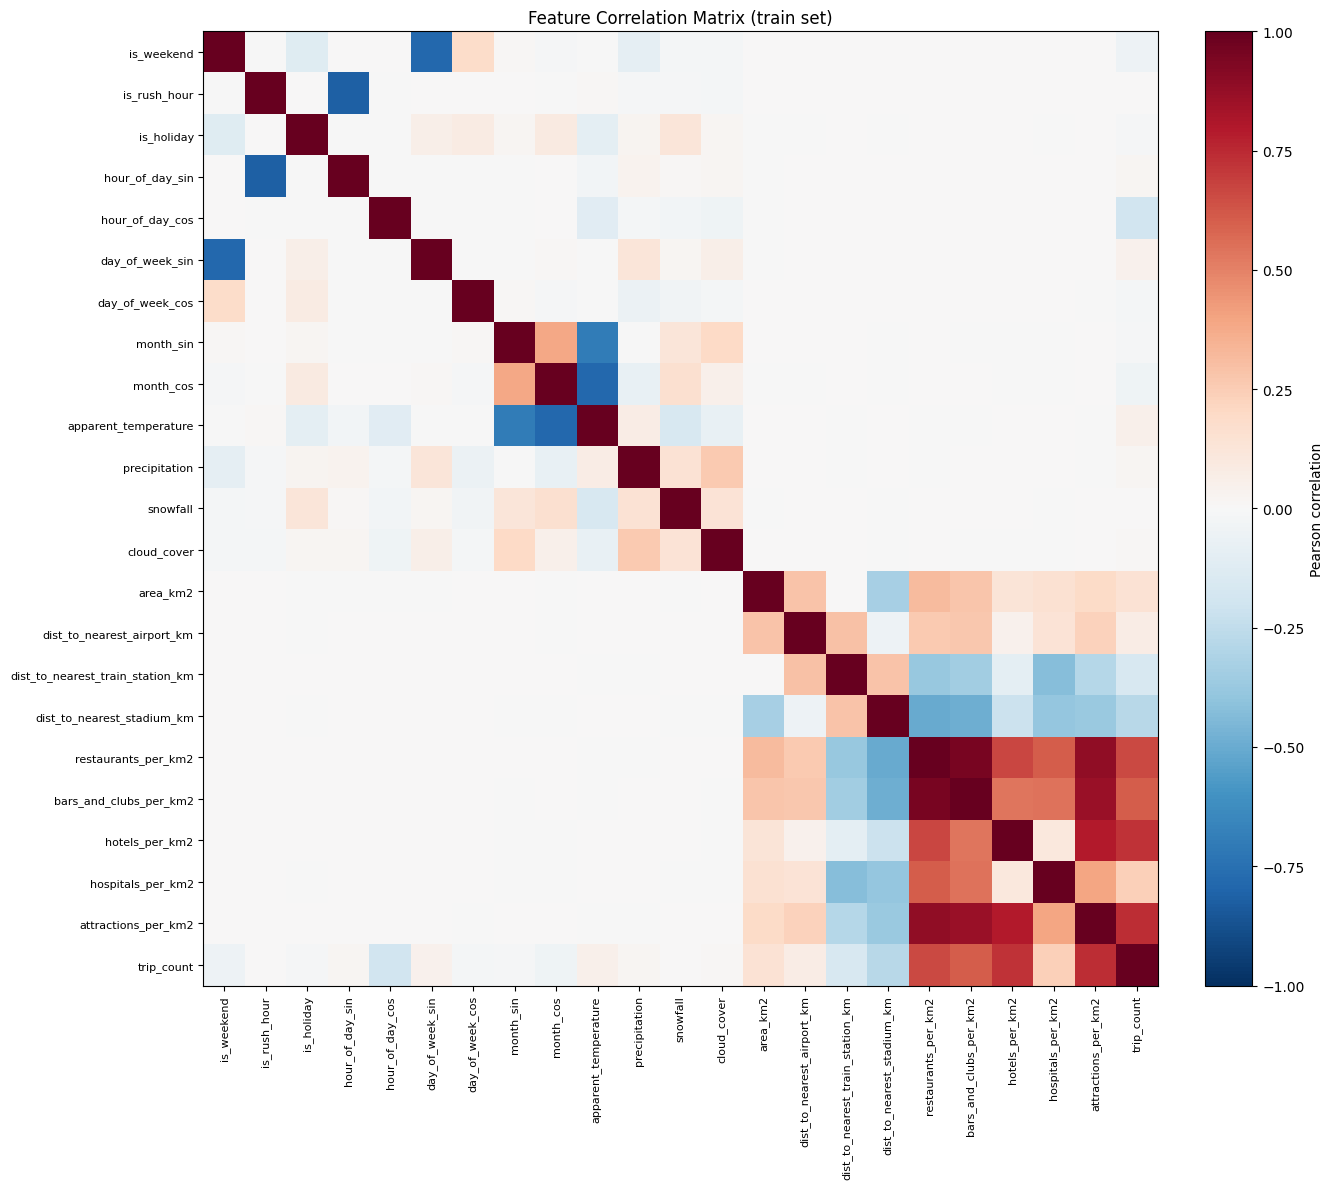

Feature pairs with |correlation| >= 0.8:
  restaurants_per_km2                 vs bars_and_clubs_per_km2               r=+0.952
  restaurants_per_km2                 vs attractions_per_km2                  r=+0.888
  bars_and_clubs_per_km2              vs attractions_per_km2                  r=+0.863
  is_rush_hour                        vs hour_of_day_sin                      r=-0.816


In [52]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Correlation Matrix                      #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

corr_cols   = FEATURE_COLS + [TARGET_COL]
corr_matrix = train_data[corr_cols].corr()

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(corr_matrix.values, cmap="RdBu_r", vmin=-1, vmax=1)

ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=90, fontsize=8)
ax.set_yticklabels(corr_cols, fontsize=8)

fig.colorbar(im, ax=ax, label="Pearson correlation", fraction=0.046, pad=0.04)
ax.set_title("Feature Correlation Matrix (train set)")
plt.tight_layout()
plt.show()

# Highly correlated feature pairs -> candidates for removal
THRESHOLD = 0.8
pairs = []
for i in range(len(corr_cols)):
    for j in range(i + 1, len(corr_cols)):
        c = corr_matrix.iloc[i, j]
        if abs(c) >= THRESHOLD:
            pairs.append((corr_cols[i], corr_cols[j], c))
pairs.sort(key=lambda x: -abs(x[2]))

print(f"Feature pairs with |correlation| >= {THRESHOLD}:")
if pairs:
    for a, b, c in pairs:
        print(f"  {a:<35s} vs {b:<35s}  r={c:+.3f}")
else:
    print("  none")

In [53]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Model-Based Feature Importance          #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance

rf = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=0, n_jobs=-1)
rf.fit(train_data[FEATURE_COLS], train_data[TARGET_COL])

perm = permutation_importance(
    rf, train_data[FEATURE_COLS], train_data[TARGET_COL],
    n_repeats=10, random_state=0, n_jobs=-1,
)

importance_df = pd.DataFrame({
    "feature":             FEATURE_COLS,
    "rf_importance":       rf.feature_importances_,
    "perm_importance":     perm.importances_mean,
    "perm_importance_std": perm.importances_std,
}).sort_values("perm_importance", ascending=False).reset_index(drop=True)

print(importance_df.to_string(index=False))

# Features that don't measurably help (or hurt) the model when shuffled
LOW_IMPORTANCE = importance_df.loc[importance_df["perm_importance"] <= 0, "feature"].tolist()
print(f"\nFeatures with permutation importance <= 0 (no measurable contribution, or hurting the model):")
print(f"  {LOW_IMPORTANCE if LOW_IMPORTANCE else 'none'}")

                         feature  rf_importance  perm_importance  perm_importance_std
                 hour_of_day_cos       0.239574         0.551822             0.011896
             attractions_per_km2       0.203973         0.245614             0.003489
             restaurants_per_km2       0.162355         0.137343             0.002496
                  hotels_per_km2       0.171145         0.129032             0.002765
          bars_and_clubs_per_km2       0.065910         0.055399             0.000544
      dist_to_nearest_airport_km       0.024993         0.055263             0.000790
                 day_of_week_sin       0.027851         0.046280             0.001603
                 hour_of_day_sin       0.016926         0.026819             0.000659
                       month_cos       0.016591         0.026791             0.001288
                      is_weekend       0.016445         0.018067             0.000807
                 day_of_week_cos       0.005449       

## 4.2.8 Benchmark Models

Before diving into the three NN architectures, we evaluate two simple non-neural baselines on the held-out test set:

1. **Historical-mean predictor** — for each hexagon × hour-of-day pair, predict the mean `trip_count` observed in the training split. Unseen combinations fall back to the global training mean.
2. **Ridge regression** — a linear model on the same scaled feature matrix (`X_train`). Trained on log₁⁺ demand and back-transformed with `expm1` at evaluation time, matching the NN target encoding.

These numbers set the floor: any NN that cannot beat Ridge is not adding value.

Metrics match the NN evaluation cells:
- **R²** — coefficient of determination
- **MAE** — mean absolute error (in raw trip counts)
- **RMSE** — root mean squared error
- **NRMSE** — RMSE normalised by mean actual demand (scale-free)

In [54]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Benchmark Models                        #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

zero_demand_count = int((y_test == 0).sum())
zero_demand_pct   = 100.0 * zero_demand_count / len(y_test)
mean_actual       = float(y_test.mean())
ss_tot            = float(np.sum((y_test - mean_actual) ** 2))

print(f"Zero-demand rows : {zero_demand_count:,} / {len(y_test):,} ({zero_demand_pct:.1f}%)")
print(f"Mean actual test demand : {mean_actual:.4f}\n")


def _eval_benchmark(label, preds):
    mae   = float(np.mean(np.abs(preds - y_test)))
    rmse  = float(np.sqrt(np.mean((preds - y_test) ** 2)))
    nrmse = rmse / mean_actual if mean_actual > 0 else float("nan")
    r2    = 1.0 - float(np.sum((preds - y_test) ** 2)) / ss_tot
    print(f"{label:<35s}  R²={r2:.4f}  MAE={mae:.4f}  RMSE={rmse:.4f}  NRMSE={nrmse:.4f}")
    return dict(r2=round(r2, 6), mae=round(mae, 6), rmse=round(rmse, 6), nrmse=round(nrmse, 6))


# ── 1. Historical-mean predictor ───────────────────────────────────────────────
mean_table = (
    train_data.groupby(['pickup_h3_res6', 'hour_of_day'])['trip_count']
    .mean()
    .rename('pred_mean')
)
global_mean = float(train_data['trip_count'].mean())

test_lookup      = test_data[['pickup_h3_res6', 'hour_of_day']].copy()
test_lookup      = test_lookup.join(mean_table, on=['pickup_h3_res6', 'hour_of_day'])
hist_mean_preds  = test_lookup['pred_mean'].fillna(global_mean).values

bm_hist = _eval_benchmark("Historical mean (hex × hour)", hist_mean_preds)

# ── 2. Ridge regression ────────────────────────────────────────────────────────
ridge        = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)            # y_train is raw counts (Poisson) or log1p-transformed
ridge_preds  = ridge.predict(X_test) if IS_POISSON else np.expm1(ridge.predict(X_test))
ridge_preds  = np.maximum(ridge_preds, 0.0)   # clamp to non-negative

bm_ridge = _eval_benchmark("Ridge regression", ridge_preds)


Zero-demand rows : 1,215 / 7,227 (16.8%)
Mean actual test demand : 105.4146

Historical mean (hex × hour)         R²=0.8584  MAE=38.8114  RMSE=120.1507  NRMSE=1.1398
Ridge regression                     R²=0.6508  MAE=71.1993  RMSE=188.6610  NRMSE=1.7897


## Embed Dimension Search

Since `embed_dim` is independent of architecture depth and width, we search it once on
the baseline and fix the winner globally for all three models.

Candidates: `[8, 16, 32]` — 3 runs total (1 seed, early stopping).


In [55]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Embed Dimension Search                  #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

EMBED_CANDIDATES = [8, 16, 32]

print(f"Embed search — ARCH_BASELINE, seed=0, patience={HP_PATIENCE}\n")
embed_results = []
for emb in EMBED_CANDIDATES:
    _, val_loss, _ = train_model(
        ARCH_BASELINE, X_train, y_train, X_val, y_val,
        hex_train, hex_val,
        seed=0, device=device, verbose=False,
        lr=config.LEARNING_RATE, embed_dim=emb, patience=HP_PATIENCE,
    )
    embed_results.append((emb, val_loss))
    print(f"  embed_dim={emb:>3}  val_loss={val_loss:.4f}")

best_embed_dim = min(embed_results, key=lambda x: x[1])[0]
HEX_EMBED_DIM        = best_embed_dim
config.HEX_EMBED_DIM = best_embed_dim
print(f"\nBest embed_dim: {HEX_EMBED_DIM}  →  set as global HEX_EMBED_DIM")


Embed search — ARCH_BASELINE, seed=0, patience=10

  embed_dim=  8  val_loss=3.8766
  embed_dim= 16  val_loss=3.8084
  embed_dim= 32  val_loss=3.8110

Best embed_dim: 16  →  set as global HEX_EMBED_DIM


## 4.2.9 Baseline Model — Training

Run `ARCH_BASELINE = (2 hidden layers, 64 units)` across all seeds and report
the mean ± std validation loss.


In [56]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Baseline Model — Visualization          #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

input_dim = X_train.shape[1]
n_layers, width = ARCH_BASELINE

viz_model = DemandBaseline(input_dim, n_layers, width, N_HEX, HEX_EMBED_DIM)
x_dummy   = torch.zeros(1, input_dim)
h_dummy   = torch.zeros(1, dtype=torch.long)
summary(viz_model, input_data=(x_dummy, h_dummy), col_names=["input_size", "output_size", "num_params"], verbose=1)


Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
DemandBaseline                           [1, 22]                   [1]                       1
├─Embedding: 1-1                         [1]                       [1, 16]                   544
├─Sequential: 1-2                        [1, 38]                   [1, 1]                    --
│    └─Linear: 2-1                       [1, 38]                   [1, 64]                   2,496
│    └─ReLU: 2-2                         [1, 64]                   [1, 64]                   --
│    └─Linear: 2-3                       [1, 64]                   [1, 64]                   4,160
│    └─ReLU: 2-4                         [1, 64]                   [1, 64]                   --
│    └─Linear: 2-5                       [1, 64]                   [1, 1]                    65
Total params: 7,266
Trainable params: 7,266
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.01
Input size (MB): 

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
DemandBaseline                           [1, 22]                   [1]                       1
├─Embedding: 1-1                         [1]                       [1, 16]                   544
├─Sequential: 1-2                        [1, 38]                   [1, 1]                    --
│    └─Linear: 2-1                       [1, 38]                   [1, 64]                   2,496
│    └─ReLU: 2-2                         [1, 64]                   [1, 64]                   --
│    └─Linear: 2-3                       [1, 64]                   [1, 64]                   4,160
│    └─ReLU: 2-4                         [1, 64]                   [1, 64]                   --
│    └─Linear: 2-5                       [1, 64]                   [1, 1]                    65
Total params: 7,266
Trainable params: 7,266
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.01
Input size (MB): 

In [57]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Baseline Model — Training               #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

print(f"Device: {device}\n")

baseline_train_losses = []
baseline_val_losses   = []
baseline_models      = []

for seed in SEEDS:
    model, val_loss, train_loss = train_model(
        ARCH_BASELINE, X_train, y_train, X_val, y_val,
        hex_train, hex_val,
        seed=seed, device=device,
    )
    baseline_train_losses.append(train_loss)
    baseline_val_losses.append(val_loss)
    baseline_models.append(model)

arch_label = ARCH_NAMES.get(ARCH_BASELINE, "baseline")
print(f"\n{arch_label}  train: {np.mean(baseline_train_losses):.4f} \u00b1 {np.std(baseline_train_losses):.4f}  val: {np.mean(baseline_val_losses):.4f} \u00b1 {np.std(baseline_val_losses):.4f}")

Device: cpu

Epoch   1/200


  0%|          | 0/33 [00:00<?, ?step/s]

  loss: 38.7585  val_loss: 44.3354 ✓
Epoch   2/200


  0%|          | 0/33 [00:00<?, ?step/s]

  loss: 31.5727  val_loss: 36.4026 ✓
Epoch   3/200


...

  loss: 3.8454  val_loss: 3.8106 ✓
Epoch 199/200


  0%|          | 0/33 [00:00<?, ?step/s]

  loss: 3.8439  val_loss: 3.8096 ✓
Epoch 200/200


  0%|          | 0/33 [00:00<?, ?step/s]

  loss: 3.8429  val_loss: 3.8084 ✓

baseline  train: 3.8429 ± 0.0000  val: 3.8084 ± 0.0000


### 4.2.9 Baseline Model — Evaluation

Evaluate on the held-out **test set** using the best-checkpoint model from each
seed, then report mean ± std across seeds.

Metrics:
- **Zero-demand rows** — share of test rows with `trip_count = 0` (context for inflated R²)
- **Mean Actual Test Demand** — average true trip count in the test set
- **R²** — coefficient of determination (share of variance explained)
- **MAE** — mean absolute error (interpretable in trip counts)
- **RMSE** — root mean squared error (penalises large misses more)
- **NRMSE** — RMSE normalised by mean actual demand (scale-free)

In [58]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Baseline Model — Evaluation             #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

from sklearn.metrics import mean_poisson_deviance, d2_tweedie_score

X_test_t   = torch.as_tensor(X_test,   dtype=torch.float32).to(device)
hex_test_t = torch.as_tensor(hex_test, dtype=torch.long).to(device)

run_results  = []
r2_scores,     mae_scores,     rmse_scores,     nrmse_scores     = [], [], [], []
d2_scores,     dev_scores = [], []
r2_log_scores, mae_log_scores, rmse_log_scores, nrmse_log_scores = [], [], [], []
correct_zero_counts, false_zero_counts = [], []
pred_min_scores, pred_max_scores = [], []
test_losses                                       = []
n_layers, width = ARCH_BASELINE

zero_demand_count = int((y_test == 0).sum())
zero_demand_pct   = 100.0 * zero_demand_count / len(y_test)
mean_actual       = float(y_test.mean())
ss_tot            = float(np.sum((y_test - mean_actual) ** 2))

y_test_log  = np.log1p(y_test)
mean_log    = float(y_test_log.mean())
ss_tot_log  = float(np.sum((y_test_log - mean_log) ** 2))

print(f"Zero-demand rows: {zero_demand_count:,} / {len(y_test):,} ({zero_demand_pct:.1f}%)")
print(f"Mean actual test demand : {mean_actual:.4f}  (min={y_test.min():.4f}, max={y_test.max():.4f})\n")

for seed, model in zip(SEEDS, baseline_models):
    model.eval()

    print(f"  seed={seed} layer weight stats:")
    for name, param in model.named_parameters():
        if "weight" in name:
            w = param.detach().cpu().numpy()
            print(f"    {name:<14s}  shape={str(tuple(w.shape)):<12}"
                  f"  max|w|={np.abs(w).max():.4f}  mean|w|={np.abs(w).mean():.4f}  norm={np.linalg.norm(w):.4f}")

    with torch.no_grad():
        preds_raw = model(X_test_t, hex_test_t).cpu().numpy().flatten()
    preds     = np.exp(preds_raw) if IS_POISSON else np.expm1(preds_raw)
    preds_log = np.log1p(preds)
    pred_min, pred_max = float(preds.min()), float(preds.max())

    mae   = float(np.mean(np.abs(preds - y_test)))
    rmse  = float(np.sqrt(np.mean((preds - y_test) ** 2)))
    nrmse = rmse / mean_actual if mean_actual > 0 else float("nan")
    r2    = 1.0 - float(np.sum((preds - y_test) ** 2)) / ss_tot

    preds_safe = np.clip(preds, 1e-9, None)
    dev   = float(mean_poisson_deviance(y_test, preds_safe))
    d2    = float(d2_tweedie_score(y_test, preds_safe, power=1))

    mae_log   = float(np.mean(np.abs(preds_log - y_test_log)))
    rmse_log  = float(np.sqrt(np.mean((preds_log - y_test_log) ** 2)))
    nrmse_log = rmse_log / mean_log if mean_log > 0 else float("nan")
    r2_log    = 1.0 - float(np.sum((preds_log - y_test_log) ** 2)) / ss_tot_log

    zero_actual  = (y_test == 0)
    zero_pred    = (preds < 0.5)
    correct_zero = int(np.sum(zero_actual & zero_pred))
    false_zero   = int(np.sum(~zero_actual & zero_pred))

    r2_scores.append(r2);         mae_scores.append(mae)
    d2_scores.append(d2);         dev_scores.append(dev)
    rmse_scores.append(rmse);     nrmse_scores.append(nrmse)
    r2_log_scores.append(r2_log); mae_log_scores.append(mae_log)
    rmse_log_scores.append(rmse_log); nrmse_log_scores.append(nrmse_log)
    correct_zero_counts.append(correct_zero)
    false_zero_counts.append(false_zero)
    pred_min_scores.append(pred_min); pred_max_scores.append(pred_max)
    test_losses.append(float(np.mean((preds_log - y_test_log) ** 2)))

    print(f"  seed={seed}"
          f"  R\u00b2={r2:.4f}  D\u00b2={d2:.4f}  MAE={mae:.4f}  NRMSE={nrmse:.4f}"
          f"  | log  R\u00b2={r2_log:.4f}  MAE={mae_log:.4f}  NRMSE={nrmse_log:.4f}"
          f"  | zeros {correct_zero:,}/{zero_demand_count:,}  false={false_zero:,}"
          f"  | pred min={pred_min:.1f} max={pred_max:.1f}")

    run_results.append({
        "timestamp"         : datetime.datetime.now().isoformat(timespec="seconds"),
        "training_loss"     : config.LOSS,
        "model"             : ARCH_NAMES.get((n_layers, width), "unknown"),
        "n_layers"          : n_layers,
        "width"             : width,
        "learning_rate"     : config.LEARNING_RATE,
        "weight_decay"      : getattr(config, "WEIGHT_DECAY", 0.0),
        "batch_size"        : BATCH_SIZE,
        "seed"              : seed,
        "hidden_activation" : getattr(config, "HIDDEN_ACTIVATION", "relu"),
        "val_loss"          : baseline_val_losses[seed],
        "zero_demand_count" : zero_demand_count,
        "mean_actual"       : round(mean_actual, 6),
        "r2"                : round(r2,       6),
        "d2"                : round(d2,       6),
        "poisson_deviance"  : round(dev,      6),
        "mae"               : round(mae,      6),
        "rmse"              : round(rmse,     6),
        "nrmse"             : round(nrmse,    6),
        "r2_log"            : round(r2_log,   6),
        "mae_log"           : round(mae_log,  6),
        "rmse_log"          : round(rmse_log, 6),
        "nrmse_log"         : round(nrmse_log,6),
        "correct_zero"      : correct_zero,
        "false_zero"        : false_zero,
        "pred_min"          : round(pred_min, 6),
        "pred_max"          : round(pred_max, 6),
    })

arch_label = ARCH_NAMES.get((n_layers, width), "model")
print(f"\n--- original scale ---")
print(f"{arch_label.capitalize()}  R\u00b2    : {np.mean(r2_scores):.4f} \u00b1 {np.std(r2_scores):.4f}")
print(f"{arch_label.capitalize()}  D\u00b2    : {np.mean(d2_scores):.4f} \u00b1 {np.std(d2_scores):.4f}")
print(f"{arch_label.capitalize()}  MAE   : {np.mean(mae_scores):.4f} \u00b1 {np.std(mae_scores):.4f}")
print(f"{arch_label.capitalize()}  RMSE  : {np.mean(rmse_scores):.4f} \u00b1 {np.std(rmse_scores):.4f}")
print(f"{arch_label.capitalize()}  NRMSE : {np.mean(nrmse_scores):.4f} \u00b1 {np.std(nrmse_scores):.4f}")
print(f"\n--- log1p scale ---")
print(f"{arch_label.capitalize()}  R\u00b2    : {np.mean(r2_log_scores):.4f} \u00b1 {np.std(r2_log_scores):.4f}")
print(f"{arch_label.capitalize()}  MAE   : {np.mean(mae_log_scores):.4f} \u00b1 {np.std(mae_log_scores):.4f}")
print(f"{arch_label.capitalize()}  RMSE  : {np.mean(rmse_log_scores):.4f} \u00b1 {np.std(rmse_log_scores):.4f}")
print(f"{arch_label.capitalize()}  NRMSE : {np.mean(nrmse_log_scores):.4f} \u00b1 {np.std(nrmse_log_scores):.4f}")
print(f"\n--- zero-demand ---")
print(f"{arch_label.capitalize()}  Correct-zero : {np.mean(correct_zero_counts):.1f} \u00b1 {np.std(correct_zero_counts):.1f}  (out of {zero_demand_count:,})")
print(f"{arch_label.capitalize()}  False-zero   : {np.mean(false_zero_counts):.1f} \u00b1 {np.std(false_zero_counts):.1f}  (predicted 0 when demand > 0)")

print(f"\n--- prediction range (raw scale) ---")
print(f"{arch_label.capitalize()}  Pred min : {np.mean(pred_min_scores):.4f} ± {np.std(pred_min_scores):.4f}")
print(f"{arch_label.capitalize()}  Pred max : {np.mean(pred_max_scores):.4f} ± {np.std(pred_max_scores):.4f}  (actual max: {y_test.max():.4f})")

print(f"\n--- overfitting check (MSE, log1p scale) ---")
print(f"  {'':<8}  {'train':>8}  {'val':>8}  {'test':>8}")
for _s, _tr, _vl, _tl in zip(SEEDS, baseline_train_losses, baseline_val_losses, test_losses):
    print(f"  seed={_s:<4}  {_tr:>8.4f}  {_vl:>8.4f}  {_tl:>8.4f}")
if len(SEEDS) > 1:
    print(f"  {'mean':<8}  {np.mean(baseline_train_losses):>8.4f}  {np.mean(baseline_val_losses):>8.4f}  {np.mean(test_losses):>8.4f}")

Zero-demand rows: 1,215 / 7,227 (16.8%)
Mean actual test demand : 105.4146  (min=0.0000, max=3645.0000)

  seed=0 layer weight stats:
    hex_embed.weight  shape=(34, 16)      max|w|=0.3318  mean|w|=0.0715  norm=2.3676
    net.0.weight    shape=(64, 38)      max|w|=0.9779  mean|w|=0.2014  norm=12.5469
    net.2.weight    shape=(64, 64)      max|w|=0.6808  mean|w|=0.1456  norm=11.6097
    net.4.weight    shape=(1, 64)       max|w|=0.4433  mean|w|=0.1499  norm=1.4879
  seed=0  R²=0.5700  D²=0.8474  MAE=54.0808  NRMSE=1.9859  | log  R²=0.9023  MAE=0.4592  NRMSE=0.2325  | zeros 722/1,215  false=87  | pred min=0.0 max=4146.2

--- original scale ---
Baseline  R²    : 0.5700 ± 0.0000
Baseline  D²    : 0.8474 ± 0.0000
Baseline  MAE   : 54.0808 ± 0.0000
Baseline  RMSE  : 209.3442 ± 0.0000
Baseline  NRMSE : 1.9859 ± 0.0000

--- log1p scale ---
Baseline  R²    : 0.9023 ± 0.0000
Baseline  MAE   : 0.4592 ± 0.0000
Baseline  RMSE  : 0.6169 ± 0.0000
Baseline  NRMSE : 0.2325 ± 0.0000

--- zero-demand -

In [59]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Save Results                            #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

RESULTS_PATH = "data/results/nn_results_hex_6_6h.csv"
os.makedirs(os.path.dirname(RESULTS_PATH), exist_ok=True)

results_df = pd.DataFrame(run_results)

if os.path.exists(RESULTS_PATH):
    existing_df = pd.read_csv(RESULTS_PATH)
    combined_df = pd.concat([existing_df, results_df], ignore_index=True, sort=False)
    combined_df.to_csv(RESULTS_PATH, index=False)
    print(f"Appended {len(results_df)} rows to {RESULTS_PATH} ({combined_df.shape[1]} columns)")
else:
    results_df.to_csv(RESULTS_PATH, index=False)
    print(f"Created {RESULTS_PATH} with {len(results_df)} rows")

print(pd.read_csv(RESULTS_PATH).tail(len(results_df)).to_string(index=False))


Appended 1 rows to data/results/nn_results_hex_6_6h.csv (28 columns)
          timestamp training_loss    model  n_layers  width  learning_rate  weight_decay  batch_size  seed  val_loss  zero_demand_count  mean_actual       r2       mae       rmse    nrmse   r2_log  mae_log  rmse_log  nrmse_log  correct_zero  false_zero  pred_min   pred_max  overfitting_measures hidden_activation       d2  poisson_deviance
2026-07-13T17:49:43        nb_nll baseline         2     64        0.00005           0.0        1024     0   3.80835               1215   105.414557 0.569985 54.080775 209.344156 1.985913 0.902256 0.459214  0.616919   0.232462           722          87  0.025497 4146.15625                   NaN              relu 0.847438         53.853439


## 4.2.10 Hyperparameter Search — Baseline Model

Grid search over 4 hyperparameters using the best LR from the LR search above.

| Hyperparameter | Candidates |
|---|---|
| `lr`           | 2e-5, 3e-5, 4e-5, 5e-5, 6e-5, 7e-5, 1e-4 |

Full grid: 4 × 4 × 3 = **48 combinations** × 1 seed = **48 training runs**.  
The best combination is stored in `BEST_HP[ARCH_BASELINE]`.


In [60]:
# HP search candidates — Baseline (2 layers × 64 units)
# Previous grid [4e-2..8e-2] × [2e-3..8e-3]: best (lr = 4e-2, wd = 8e-3) sat on
# the low-LR and high-WD edges -> re-centred both ranges around it
LR_CANDIDATES_BASELINE = [1e-2, 2e-2, 3e-2, 4e-2, 5e-2]

# Weight decay grid (0 = unregularized control). To keep the lr × wd grid
# small, pin LR_CANDIDATES_BASELINE to its best value first.
WD_CANDIDATES_BASELINE = [6e-3, 8e-3, 1e-2, 1.5e-2, 2e-2]

In [61]:
run_hp_search(
    ARCH_BASELINE,
    X_train, y_train, X_val, y_val,
    hex_train, hex_val,
    device=device,
    lr_candidates=LR_CANDIDATES_BASELINE,
    wd_candidates=WD_CANDIDATES_BASELINE,
)

HP Search — baseline
25 combos × 1 seed(s) = 25 runs  |  patience=10

   #        lr        wd    mean val       std
---------------------------------------------
   1     1e-02     6e-03      3.3361    0.0000
   2     1e-02     8e-03      3.3315    0.0000
   3     1e-02     1e-02      3.3383    0.0000
   4     1e-02     1e-02      3.3385    0.0000
   5     1e-02     2e-02      3.3283    0.0000
   6     2e-02     6e-03      3.3361    0.0000
   7     2e-02     8e-03      3.3484    0.0000
   8     2e-02     1e-02      3.3385    0.0000
   9     2e-02     1e-02      3.3428    0.0000
  10     2e-02     2e-02      3.3092    0.0000
  11     3e-02     6e-03      3.3366    0.0000
  12     3e-02     8e-03      3.3374    0.0000
  13     3e-02     1e-02      3.3307    0.0000
  14     3e-02     1e-02      3.3120    0.0000
  15     3e-02     2e-02      3.3271    0.0000
  16     4e-02     6e-03      3.3255    0.0000
  17     4e-02     8e-03      3.3289    0.0000
  18     4e-02     1e-02      3.3622  

/Users/anthony/Documents/Dokumente – MacBook Pro von Anthony/UNI/AAA/AAA_TA_2026/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:188: RuntimeWarning: invalid value encountered in subtract
  x = um.subtract(arr, arrmean, out=...)


  22     5e-02     8e-03         inf       nan
  23     5e-02     1e-02         inf       nan
  24     5e-02     1e-02         inf       nan
  25     5e-02     2e-02         inf       nan

--- Top 5 ---
  lr  weight_decay  mean_val_loss  std_val_loss
0.02         0.020       3.309187           0.0
0.03         0.015       3.312007           0.0
0.04         0.006       3.325496           0.0
0.03         0.020       3.327052           0.0
0.01         0.020       3.328282           0.0

BEST_HP[baseline] = {'lr': 0.02, 'weight_decay': 0.02}


{'lr': 0.02, 'weight_decay': 0.02}

### 4.2.10 Tuned Baseline — Training

Re-train the baseline architecture with the best hyperparameters found above,
across all `SEEDS` for a stable mean ± std estimate.


In [62]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Tuned Baseline — Training              #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

hp = BEST_HP[ARCH_BASELINE]
print(f"Best HP: {hp}\n")

tuned_train_losses = []
tuned_val_losses   = []
tuned_models      = []

for seed in SEEDS:
    model, val_loss, train_loss = train_model(
        ARCH_BASELINE, X_train, y_train, X_val, y_val,
        hex_train, hex_val,
        seed=seed, device=device,
        lr=hp["lr"],
        weight_decay=hp.get("weight_decay", 0.0),
    )
    tuned_train_losses.append(train_loss)
    tuned_val_losses.append(val_loss)
    tuned_models.append(model)

arch_label = ARCH_NAMES.get(ARCH_BASELINE, "baseline")
print(f"\n{arch_label}  train: {np.mean(tuned_train_losses):.4f} \u00b1 {np.std(tuned_train_losses):.4f}  val: {np.mean(tuned_val_losses):.4f} \u00b1 {np.std(tuned_val_losses):.4f}")

Best HP: {'lr': 0.02, 'weight_decay': 0.02}

Epoch   1/200


  0%|          | 0/33 [00:00<?, ?step/s]

  loss: 7.6565  val_loss: 4.2705 ✓
Epoch   2/200


  0%|          | 0/33 [00:00<?, ?step/s]

  loss: 4.1505  val_loss: 4.0031 ✓
Epoch   3/200


...

  loss: 3.1019  val_loss: 3.3734  (no improvement 8/10)
Epoch  45/200


  0%|          | 0/33 [00:00<?, ?step/s]

  loss: 3.1018  val_loss: 3.3598  (no improvement 9/10)
Epoch  46/200


  0%|          | 0/33 [00:00<?, ?step/s]

  loss: 3.1309  val_loss: 3.4234  (no improvement 10/10)

  ↳ early stop at epoch 46  best_val=3.3092  best_train=3.1450

baseline  train: 3.1450 ± 0.0000  val: 3.3092 ± 0.0000


### 4.2.10 Tuned Baseline — Evaluation

Evaluate on the held-out **test set** and compare against the untuned baseline.


In [63]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Tuned Baseline — Evaluation             #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

from sklearn.metrics import mean_poisson_deviance, d2_tweedie_score

X_test_t   = torch.as_tensor(X_test,   dtype=torch.float32).to(device)
hex_test_t = torch.as_tensor(hex_test, dtype=torch.long).to(device)

run_results  = []
r2_scores,     mae_scores,     rmse_scores,     nrmse_scores     = [], [], [], []
d2_scores,     dev_scores = [], []
r2_log_scores, mae_log_scores, rmse_log_scores, nrmse_log_scores = [], [], [], []
correct_zero_counts, false_zero_counts = [], []
pred_min_scores, pred_max_scores = [], []
test_losses                                       = []
n_layers, width = ARCH_BASELINE

zero_demand_count = int((y_test == 0).sum())
zero_demand_pct   = 100.0 * zero_demand_count / len(y_test)
mean_actual       = float(y_test.mean())
ss_tot            = float(np.sum((y_test - mean_actual) ** 2))

y_test_log  = np.log1p(y_test)
mean_log    = float(y_test_log.mean())
ss_tot_log  = float(np.sum((y_test_log - mean_log) ** 2))

print(f"Zero-demand rows: {zero_demand_count:,} / {len(y_test):,} ({zero_demand_pct:.1f}%)")
print(f"Mean actual test demand : {mean_actual:.4f}  (min={y_test.min():.4f}, max={y_test.max():.4f})\n")

for seed, model in zip(SEEDS, tuned_models):
    model.eval()

    with torch.no_grad():
        preds_raw = model(X_test_t, hex_test_t).cpu().numpy().flatten()
    preds     = np.exp(preds_raw) if IS_POISSON else np.expm1(preds_raw)
    preds_log = np.log1p(preds)
    pred_min, pred_max = float(preds.min()), float(preds.max())

    mae   = float(np.mean(np.abs(preds - y_test)))
    rmse  = float(np.sqrt(np.mean((preds - y_test) ** 2)))
    nrmse = rmse / mean_actual if mean_actual > 0 else float("nan")
    r2    = 1.0 - float(np.sum((preds - y_test) ** 2)) / ss_tot

    preds_safe = np.clip(preds, 1e-9, None)
    dev   = float(mean_poisson_deviance(y_test, preds_safe))
    d2    = float(d2_tweedie_score(y_test, preds_safe, power=1))

    mae_log   = float(np.mean(np.abs(preds_log - y_test_log)))
    rmse_log  = float(np.sqrt(np.mean((preds_log - y_test_log) ** 2)))
    nrmse_log = rmse_log / mean_log if mean_log > 0 else float("nan")
    r2_log    = 1.0 - float(np.sum((preds_log - y_test_log) ** 2)) / ss_tot_log

    zero_actual  = (y_test == 0)
    zero_pred    = (preds < 0.5)
    correct_zero = int(np.sum(zero_actual & zero_pred))
    false_zero   = int(np.sum(~zero_actual & zero_pred))

    r2_scores.append(r2);         mae_scores.append(mae)
    d2_scores.append(d2);         dev_scores.append(dev)
    rmse_scores.append(rmse);     nrmse_scores.append(nrmse)
    r2_log_scores.append(r2_log); mae_log_scores.append(mae_log)
    rmse_log_scores.append(rmse_log); nrmse_log_scores.append(nrmse_log)
    correct_zero_counts.append(correct_zero)
    false_zero_counts.append(false_zero)
    pred_min_scores.append(pred_min); pred_max_scores.append(pred_max)
    test_losses.append(float(np.mean((preds_log - y_test_log) ** 2)))

    print(f"  seed={seed}"
          f"  R\u00b2={r2:.4f}  D\u00b2={d2:.4f}  MAE={mae:.4f}  NRMSE={nrmse:.4f}"
          f"  | log  R\u00b2={r2_log:.4f}  MAE={mae_log:.4f}  NRMSE={nrmse_log:.4f}"
          f"  | zeros {correct_zero:,}/{zero_demand_count:,}  false={false_zero:,}"
          f"  | pred min={pred_min:.1f} max={pred_max:.1f}")

    run_results.append({
        "timestamp"         : datetime.datetime.now().isoformat(timespec="seconds"),
        "training_loss"     : config.LOSS,
        "model"             : "baseline_tuned",
        "n_layers"          : n_layers,
        "width"             : width,
        "learning_rate"     : BEST_HP[ARCH_BASELINE]["lr"],
        "weight_decay"      : BEST_HP[ARCH_BASELINE].get("weight_decay", 0.0),
        "batch_size"        : BATCH_SIZE,
        "seed"              : seed,
        "hidden_activation" : getattr(config, "HIDDEN_ACTIVATION", "relu"),
        "val_loss"          : tuned_val_losses[seed],
        "zero_demand_count" : zero_demand_count,
        "mean_actual"       : mean_actual,
        "r2"                : r2,
        "d2"                : round(d2,       6),
        "poisson_deviance"  : round(dev,      6),
        "mae"               : mae,
        "rmse"              : rmse,
        "nrmse"             : nrmse,
        "r2_log"            : round(r2_log,   6),
        "mae_log"           : round(mae_log,  6),
        "rmse_log"          : round(rmse_log, 6),
        "nrmse_log"         : round(nrmse_log,6),
        "correct_zero"      : correct_zero,
        "false_zero"        : false_zero,
        "pred_min"          : round(pred_min, 6),
        "pred_max"          : round(pred_max, 6),
    })

print(f"\n--- original scale ---")
print(f"Tuned Baseline  R\u00b2    : {np.mean(r2_scores):.4f} \u00b1 {np.std(r2_scores):.4f}")
print(f"Tuned Baseline  D\u00b2    : {np.mean(d2_scores):.4f} \u00b1 {np.std(d2_scores):.4f}")
print(f"Tuned Baseline  MAE   : {np.mean(mae_scores):.4f} \u00b1 {np.std(mae_scores):.4f}")
print(f"Tuned Baseline  RMSE  : {np.mean(rmse_scores):.4f} \u00b1 {np.std(rmse_scores):.4f}")
print(f"Tuned Baseline  NRMSE : {np.mean(nrmse_scores):.4f} \u00b1 {np.std(nrmse_scores):.4f}")
print(f"\n--- log1p scale ---")
print(f"Tuned Baseline  R\u00b2    : {np.mean(r2_log_scores):.4f} \u00b1 {np.std(r2_log_scores):.4f}")
print(f"Tuned Baseline  MAE   : {np.mean(mae_log_scores):.4f} \u00b1 {np.std(mae_log_scores):.4f}")
print(f"Tuned Baseline  RMSE  : {np.mean(rmse_log_scores):.4f} \u00b1 {np.std(rmse_log_scores):.4f}")
print(f"Tuned Baseline  NRMSE : {np.mean(nrmse_log_scores):.4f} \u00b1 {np.std(nrmse_log_scores):.4f}")
print(f"\n--- zero-demand ---")
print(f"Tuned Baseline  Correct-zero : {np.mean(correct_zero_counts):.1f} \u00b1 {np.std(correct_zero_counts):.1f}  (out of {zero_demand_count:,})")
print(f"Tuned Baseline  False-zero   : {np.mean(false_zero_counts):.1f} \u00b1 {np.std(false_zero_counts):.1f}  (predicted 0 when demand > 0)")

print(f"\n--- prediction range (raw scale) ---")
print(f"{arch_label.capitalize()}  Pred min : {np.mean(pred_min_scores):.4f} ± {np.std(pred_min_scores):.4f}")
print(f"{arch_label.capitalize()}  Pred max : {np.mean(pred_max_scores):.4f} ± {np.std(pred_max_scores):.4f}  (actual max: {y_test.max():.4f})")

print(f"\n--- overfitting check (MSE, log1p scale) ---")
print(f"  {'':<8}  {'train':>8}  {'val':>8}  {'test':>8}")
for _s, _tr, _vl, _tl in zip(SEEDS, tuned_train_losses, tuned_val_losses, test_losses):
    print(f"  seed={_s:<4}  {_tr:>8.4f}  {_vl:>8.4f}  {_tl:>8.4f}")
if len(SEEDS) > 1:
    print(f"  {'mean':<8}  {np.mean(tuned_train_losses):>8.4f}  {np.mean(tuned_val_losses):>8.4f}  {np.mean(test_losses):>8.4f}")

Zero-demand rows: 1,215 / 7,227 (16.8%)
Mean actual test demand : 105.4146  (min=0.0000, max=3645.0000)

  seed=0  R²=0.7795  D²=0.9264  MAE=39.7985  NRMSE=1.4222  | log  R²=0.9358  MAE=0.3706  NRMSE=0.1884  | zeros 921/1,215  false=160  | pred min=0.0 max=5681.4

--- original scale ---
Tuned Baseline  R²    : 0.7795 ± 0.0000
Tuned Baseline  D²    : 0.9264 ± 0.0000
Tuned Baseline  MAE   : 39.7985 ± 0.0000
Tuned Baseline  RMSE  : 149.9223 ± 0.0000
Tuned Baseline  NRMSE : 1.4222 ± 0.0000

--- log1p scale ---
Tuned Baseline  R²    : 0.9358 ± 0.0000
Tuned Baseline  MAE   : 0.3706 ± 0.0000
Tuned Baseline  RMSE  : 0.5001 ± 0.0000
Tuned Baseline  NRMSE : 0.1884 ± 0.0000

--- zero-demand ---
Tuned Baseline  Correct-zero : 921.0 ± 0.0  (out of 1,215)
Tuned Baseline  False-zero   : 160.0 ± 0.0  (predicted 0 when demand > 0)

--- prediction range (raw scale) ---
Baseline  Pred min : 0.0008 ± 0.0000
Baseline  Pred max : 5681.4478 ± 0.0000  (actual max: 3645.0000)

--- overfitting check (MSE, log1p

In [64]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Save Results                            #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

RESULTS_PATH = "data/results/nn_results_hex_6_6h.csv"
os.makedirs(os.path.dirname(RESULTS_PATH), exist_ok=True)

results_df = pd.DataFrame(run_results)

if os.path.exists(RESULTS_PATH):
    existing_df = pd.read_csv(RESULTS_PATH)
    combined_df = pd.concat([existing_df, results_df], ignore_index=True, sort=False)
    combined_df.to_csv(RESULTS_PATH, index=False)
    print(f"Appended {len(results_df)} rows to {RESULTS_PATH} ({combined_df.shape[1]} columns)")
else:
    results_df.to_csv(RESULTS_PATH, index=False)
    print(f"Created {RESULTS_PATH} with {len(results_df)} rows")

print(pd.read_csv(RESULTS_PATH).tail(len(results_df)).to_string(index=False))


Appended 1 rows to data/results/nn_results_hex_6_6h.csv (28 columns)
          timestamp training_loss          model  n_layers  width  learning_rate  weight_decay  batch_size  seed  val_loss  zero_demand_count  mean_actual       r2       mae       rmse    nrmse   r2_log  mae_log  rmse_log  nrmse_log  correct_zero  false_zero  pred_min    pred_max  overfitting_measures hidden_activation       d2  poisson_deviance
2026-07-13T17:51:23        nb_nll baseline_tuned         2     64           0.02          0.02        1024     0  3.309187               1215   105.414557 0.779457 39.798519 149.922265 1.422216 0.935779 0.370622   0.50006   0.188428           921         160  0.000783 5681.447754                   NaN              relu 0.926357         25.995658


## 4.2.11 Deeper Model — Training

Run `ARCH_DEEPER = (4 hidden layers, 64 units)` across all seeds.
Width is fixed; depth doubles relative to the baseline.


In [65]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Deeper   Model — Training              #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

deeper_train_losses = []
deeper_val_losses   = []
deeper_models      = []

for seed in SEEDS:
    model, val_loss, train_loss = train_model(
        ARCH_DEEPER, X_train, y_train, X_val, y_val,
        hex_train, hex_val,
        seed=seed, device=device,
    )
    deeper_train_losses.append(train_loss)
    deeper_val_losses.append(val_loss)
    deeper_models.append(model)

arch_label = ARCH_NAMES.get(ARCH_DEEPER, "deep")
print(f"\n{arch_label}  train: {np.mean(deeper_train_losses):.4f} \u00b1 {np.std(deeper_train_losses):.4f}  val: {np.mean(deeper_val_losses):.4f} \u00b1 {np.std(deeper_val_losses):.4f}")

Epoch   1/200


  0%|          | 0/33 [00:00<?, ?step/s]

  loss: 49.9872  val_loss: 42.6436 ✓
Epoch   2/200


  0%|          | 0/33 [00:00<?, ?step/s]

  loss: 29.3654  val_loss: 24.3822 ✓
Epoch   3/200


...

  loss: 3.7983  val_loss: 3.7907 ✓
Epoch 199/200


  0%|          | 0/33 [00:00<?, ?step/s]

  loss: 3.7974  val_loss: 3.7899 ✓
Epoch 200/200


  0%|          | 0/33 [00:00<?, ?step/s]

  loss: 3.7968  val_loss: 3.7882 ✓

deep  train: 3.7968 ± 0.0000  val: 3.7882 ± 0.0000


### 4.2.11 Deeper Model — Evaluation

Evaluate on the held-out **test set** using the best-checkpoint model from each
seed, then report mean ± std across seeds.

Metrics:
- **Zero-demand rows** — share of test rows with `trip_count = 0` (context for inflated R²)
- **Mean Actual Test Demand** — average true trip count in the test set
- **R²** — coefficient of determination (share of variance explained)
- **MAE** — mean absolute error (interpretable in trip counts)
- **RMSE** — root mean squared error (penalises large misses more)
- **NRMSE** — RMSE normalised by mean actual demand (scale-free)

In [66]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Deeper   Model — Evaluation             #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

from sklearn.metrics import mean_poisson_deviance, d2_tweedie_score

X_test_t   = torch.as_tensor(X_test,   dtype=torch.float32).to(device)
hex_test_t = torch.as_tensor(hex_test, dtype=torch.long).to(device)

run_results  = []
r2_scores,     mae_scores,     rmse_scores,     nrmse_scores     = [], [], [], []
d2_scores,     dev_scores = [], []
r2_log_scores, mae_log_scores, rmse_log_scores, nrmse_log_scores = [], [], [], []
correct_zero_counts, false_zero_counts = [], []
pred_min_scores, pred_max_scores = [], []
test_losses                                       = []
n_layers, width = ARCH_DEEPER

zero_demand_count = int((y_test == 0).sum())
zero_demand_pct   = 100.0 * zero_demand_count / len(y_test)
mean_actual       = float(y_test.mean())
ss_tot            = float(np.sum((y_test - mean_actual) ** 2))

y_test_log  = np.log1p(y_test)
mean_log    = float(y_test_log.mean())
ss_tot_log  = float(np.sum((y_test_log - mean_log) ** 2))

print(f"Zero-demand rows: {zero_demand_count:,} / {len(y_test):,} ({zero_demand_pct:.1f}%)")
print(f"Mean actual test demand : {mean_actual:.4f}  (min={y_test.min():.4f}, max={y_test.max():.4f})\n")

for seed, model in zip(SEEDS, deeper_models):
    model.eval()

    with torch.no_grad():
        preds_raw = model(X_test_t, hex_test_t).cpu().numpy().flatten()
    preds     = np.exp(preds_raw) if IS_POISSON else np.expm1(preds_raw)
    preds_log = np.log1p(preds)
    pred_min, pred_max = float(preds.min()), float(preds.max())

    mae   = float(np.mean(np.abs(preds - y_test)))
    rmse  = float(np.sqrt(np.mean((preds - y_test) ** 2)))
    nrmse = rmse / mean_actual if mean_actual > 0 else float("nan")
    r2    = 1.0 - float(np.sum((preds - y_test) ** 2)) / ss_tot

    preds_safe = np.clip(preds, 1e-9, None)
    dev   = float(mean_poisson_deviance(y_test, preds_safe))
    d2    = float(d2_tweedie_score(y_test, preds_safe, power=1))

    mae_log   = float(np.mean(np.abs(preds_log - y_test_log)))
    rmse_log  = float(np.sqrt(np.mean((preds_log - y_test_log) ** 2)))
    nrmse_log = rmse_log / mean_log if mean_log > 0 else float("nan")
    r2_log    = 1.0 - float(np.sum((preds_log - y_test_log) ** 2)) / ss_tot_log

    zero_actual  = (y_test == 0)
    zero_pred    = (preds < 0.5)
    correct_zero = int(np.sum(zero_actual & zero_pred))
    false_zero   = int(np.sum(~zero_actual & zero_pred))

    r2_scores.append(r2);         mae_scores.append(mae)
    d2_scores.append(d2);         dev_scores.append(dev)
    rmse_scores.append(rmse);     nrmse_scores.append(nrmse)
    r2_log_scores.append(r2_log); mae_log_scores.append(mae_log)
    rmse_log_scores.append(rmse_log); nrmse_log_scores.append(nrmse_log)
    correct_zero_counts.append(correct_zero)
    false_zero_counts.append(false_zero)
    pred_min_scores.append(pred_min); pred_max_scores.append(pred_max)
    test_losses.append(float(np.mean((preds_log - y_test_log) ** 2)))

    print(f"  seed={seed}"
          f"  R²={r2:.4f}  D²={d2:.4f}  MAE={mae:.4f}  NRMSE={nrmse:.4f}"
          f"  | log  R²={r2_log:.4f}  MAE={mae_log:.4f}  NRMSE={nrmse_log:.4f}"
          f"  | zeros {correct_zero:,}/{zero_demand_count:,}  false={false_zero:,}"
          f"  | pred min={pred_min:.1f} max={pred_max:.1f}")

    run_results.append({
        "timestamp"         : datetime.datetime.now().isoformat(timespec="seconds"),
        "training_loss"     : config.LOSS,
        "model"             : ARCH_NAMES.get((n_layers, width), "unknown"),
        "n_layers"          : n_layers,
        "width"             : width,
        "learning_rate"     : config.LEARNING_RATE,
        "weight_decay"      : getattr(config, "WEIGHT_DECAY", 0.0),
        "batch_size"        : BATCH_SIZE,
        "seed"              : seed,
        "hidden_activation" : getattr(config, "HIDDEN_ACTIVATION", "relu"),
        "val_loss"          : deeper_val_losses[seed],
        "zero_demand_count" : zero_demand_count,
        "mean_actual"       : round(mean_actual, 6),
        "r2"                : round(r2,       6),
        "d2"                : round(d2,       6),
        "poisson_deviance"  : round(dev,      6),
        "mae"               : round(mae,      6),
        "rmse"              : round(rmse,     6),
        "nrmse"             : round(nrmse,    6),
        "r2_log"            : round(r2_log,   6),
        "mae_log"           : round(mae_log,  6),
        "rmse_log"          : round(rmse_log, 6),
        "nrmse_log"         : round(nrmse_log,6),
        "correct_zero"      : correct_zero,
        "false_zero"        : false_zero,
        "pred_min"          : round(pred_min, 6),
        "pred_max"          : round(pred_max, 6),
    })

arch_label = ARCH_NAMES.get((n_layers, width), "model")
print(f"\n--- original scale ---")
print(f"{arch_label.capitalize()}  R²    : {np.mean(r2_scores):.4f} ± {np.std(r2_scores):.4f}")
print(f"{arch_label.capitalize()}  D²    : {np.mean(d2_scores):.4f} ± {np.std(d2_scores):.4f}")
print(f"{arch_label.capitalize()}  MAE   : {np.mean(mae_scores):.4f} ± {np.std(mae_scores):.4f}")
print(f"{arch_label.capitalize()}  RMSE  : {np.mean(rmse_scores):.4f} ± {np.std(rmse_scores):.4f}")
print(f"{arch_label.capitalize()}  NRMSE : {np.mean(nrmse_scores):.4f} ± {np.std(nrmse_scores):.4f}")
print(f"\n--- log1p scale ---")
print(f"{arch_label.capitalize()}  R²    : {np.mean(r2_log_scores):.4f} ± {np.std(r2_log_scores):.4f}")
print(f"{arch_label.capitalize()}  MAE   : {np.mean(mae_log_scores):.4f} ± {np.std(mae_log_scores):.4f}")
print(f"{arch_label.capitalize()}  RMSE  : {np.mean(rmse_log_scores):.4f} ± {np.std(rmse_log_scores):.4f}")
print(f"{arch_label.capitalize()}  NRMSE : {np.mean(nrmse_log_scores):.4f} ± {np.std(nrmse_log_scores):.4f}")
print(f"\n--- zero-demand ---")
print(f"{arch_label.capitalize()}  Correct-zero : {np.mean(correct_zero_counts):.1f} ± {np.std(correct_zero_counts):.1f}  (out of {zero_demand_count:,})")
print(f"{arch_label.capitalize()}  False-zero   : {np.mean(false_zero_counts):.1f} ± {np.std(false_zero_counts):.1f}  (predicted 0 when demand > 0)")

print(f"\n--- prediction range (raw scale) ---")
print(f"{arch_label.capitalize()}  Pred min : {np.mean(pred_min_scores):.4f} ± {np.std(pred_min_scores):.4f}")
print(f"{arch_label.capitalize()}  Pred max : {np.mean(pred_max_scores):.4f} ± {np.std(pred_max_scores):.4f}  (actual max: {y_test.max():.4f})")

print(f"\n--- overfitting check (MSE, log1p scale) ---")
print(f"  {'':<8}  {'train':>8}  {'val':>8}  {'test':>8}")
for _s, _tr, _vl, _tl in zip(SEEDS, deeper_train_losses, deeper_val_losses, test_losses):
    print(f"  seed={_s:<4}  {_tr:>8.4f}  {_vl:>8.4f}  {_tl:>8.4f}")
if len(SEEDS) > 1:
    print(f"  {'mean':<8}  {np.mean(deeper_train_losses):>8.4f}  {np.mean(deeper_val_losses):>8.4f}  {np.mean(test_losses):>8.4f}")

Zero-demand rows: 1,215 / 7,227 (16.8%)
Mean actual test demand : 105.4146  (min=0.0000, max=3645.0000)

  seed=0  R²=-0.6473  D²=0.8498  MAE=55.7965  NRMSE=3.8869  | log  R²=0.9042  MAE=0.4511  NRMSE=0.2301  | zeros 821/1,215  false=121  | pred min=0.0 max=26040.3

--- original scale ---
Deep  R²    : -0.6473 ± 0.0000
Deep  D²    : 0.8498 ± 0.0000
Deep  MAE   : 55.7965 ± 0.0000
Deep  RMSE  : 409.7350 ± 0.0000
Deep  NRMSE : 3.8869 ± 0.0000

--- log1p scale ---
Deep  R²    : 0.9042 ± 0.0000
Deep  MAE   : 0.4511 ± 0.0000
Deep  RMSE  : 0.6108 ± 0.0000
Deep  NRMSE : 0.2301 ± 0.0000

--- zero-demand ---
Deep  Correct-zero : 821.0 ± 0.0  (out of 1,215)
Deep  False-zero   : 121.0 ± 0.0  (predicted 0 when demand > 0)

--- prediction range (raw scale) ---
Deep  Pred min : 0.0010 ± 0.0000
Deep  Pred max : 26040.2676 ± 0.0000  (actual max: 3645.0000)

--- overfitting check (MSE, log1p scale) ---
               train       val      test
  seed=0       3.7968    3.7882    0.3730


In [67]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Save Results                            #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

RESULTS_PATH = "data/results/nn_results_hex_6_6h.csv"
os.makedirs(os.path.dirname(RESULTS_PATH), exist_ok=True)

results_df = pd.DataFrame(run_results)

if os.path.exists(RESULTS_PATH):
    existing_df = pd.read_csv(RESULTS_PATH)
    combined_df = pd.concat([existing_df, results_df], ignore_index=True, sort=False)
    combined_df.to_csv(RESULTS_PATH, index=False)
    print(f"Appended {len(results_df)} rows to {RESULTS_PATH} ({combined_df.shape[1]} columns)")
else:
    results_df.to_csv(RESULTS_PATH, index=False)
    print(f"Created {RESULTS_PATH} with {len(results_df)} rows")

print(pd.read_csv(RESULTS_PATH).tail(len(results_df)).to_string(index=False))


Appended 1 rows to data/results/nn_results_hex_6_6h.csv (28 columns)
          timestamp training_loss model  n_layers  width  learning_rate  weight_decay  batch_size  seed  val_loss  zero_demand_count  mean_actual        r2       mae       rmse    nrmse   r2_log  mae_log  rmse_log  nrmse_log  correct_zero  false_zero  pred_min     pred_max  overfitting_measures hidden_activation       d2  poisson_deviance
2026-07-13T17:52:11        nb_nll  deep         8     64        0.00005           0.0        1024     0  3.788225               1215   105.414557 -0.647281 55.796453 409.735039 3.886892 0.904193 0.451103  0.610775   0.230146           821         121  0.000992 26040.267578                   NaN              relu 0.849838          53.00615


## 4.2.12 Hyperparameter Search — Deeper Model

Same grid search as for the baseline, run on `ARCH_DEEPER = (4 hidden layers, 64 units)`.
Result is stored in `BEST_HP[ARCH_DEEPER]`.

| Hyperparameter | Candidates |
|---|---|
| `lr`           | 2e-5, 3e-5, 4e-5, 5e-5, 6e-5, 7e-5, 1e-4 |

Full grid: 4 × 4 × 3 = **48 combinations** × 1 seed = **48 training runs**.  
The best combination is stored in `BEST_HP[ARCH_DEEPER]`.

In [68]:
# HP search candidates — Deeper (8 layers × 64 units)
# Previous grid [3e-3..9e-3]: best (lr = 3e-3, wd = 1e-3) sat on the low-LR
# edge and every higher LR was worse -> shifted the LR range down; wd was interior
LR_CANDIDATES_DEEPER   = [5e-4, 1e-3, 1.5e-3, 2e-3, 3e-3]

# Weight decay grid (0 = unregularized control). To keep the lr × wd grid
# small, pin LR_CANDIDATES_DEEPER to its best value first.
WD_CANDIDATES_DEEPER = [3e-4, 1e-3, 2e-3, 3e-3]

In [69]:
run_hp_search(
    ARCH_DEEPER,
    X_train, y_train, X_val, y_val,
    hex_train, hex_val,
    device=device,
    lr_candidates=LR_CANDIDATES_DEEPER,
    wd_candidates=WD_CANDIDATES_DEEPER,
)

HP Search — deep
20 combos × 1 seed(s) = 20 runs  |  patience=10

   #        lr        wd    mean val       std
---------------------------------------------
   1     5e-04     3e-04      3.4958    0.0000
   2     5e-04     1e-03      3.4891    0.0000
   3     5e-04     2e-03      3.5088    0.0000
   4     5e-04     3e-03      3.4949    0.0000
   5     1e-03     3e-04      3.4823    0.0000
   6     1e-03     1e-03      3.4716    0.0000
   7     1e-03     2e-03      3.4846    0.0000
   8     1e-03     3e-03      3.4684    0.0000
   9     2e-03     3e-04      3.4517    0.0000
  10     2e-03     1e-03      3.4692    0.0000
  11     2e-03     2e-03      3.4663    0.0000
  12     2e-03     3e-03      3.4655    0.0000
  13     2e-03     3e-04      3.4497    0.0000
  14     2e-03     1e-03      3.4525    0.0000
  15     2e-03     2e-03      3.4336    0.0000
  16     2e-03     3e-03      3.4620    0.0000
  17     3e-03     3e-04      3.4342    0.0000
  18     3e-03     1e-03      3.4145    0.

{'lr': 0.003, 'weight_decay': 0.003}

### 4.2.12 Tuned Deeper — Training

Re-train the deeper architecture with the best hyperparameters found above,
across all `SEEDS` for a stable mean ± std estimate.

In [70]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Tuned Deeper — Training                #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

hp = BEST_HP[ARCH_DEEPER]
print(f"Best HP: {hp}\n")

tuned_deeper_train_losses = []
tuned_deeper_val_losses   = []
tuned_deeper_models      = []

for seed in SEEDS:
    model, val_loss, train_loss = train_model(
        ARCH_DEEPER, X_train, y_train, X_val, y_val,
        hex_train, hex_val,
        seed=seed, device=device,
        lr=hp["lr"],
        weight_decay=hp.get("weight_decay", 0.0),
    )
    tuned_deeper_train_losses.append(train_loss)
    tuned_deeper_val_losses.append(val_loss)
    tuned_deeper_models.append(model)

arch_label = ARCH_NAMES.get(ARCH_DEEPER, "deep")
print(f"\n{arch_label}  train: {np.mean(tuned_deeper_train_losses):.4f} ± {np.std(tuned_deeper_train_losses):.4f}  val: {np.mean(tuned_deeper_val_losses):.4f} ± {np.std(tuned_deeper_val_losses):.4f}")

Best HP: {'lr': 0.003, 'weight_decay': 0.003}

Epoch   1/200


  0%|          | 0/33 [00:00<?, ?step/s]

  loss: 9.1457  val_loss: 4.8571 ✓
Epoch   2/200


  0%|          | 0/33 [00:00<?, ?step/s]

  loss: 4.5267  val_loss: 4.2057 ✓
Epoch   3/200


...

  loss: 3.1192  val_loss: 3.5118  (no improvement 8/10)
Epoch  86/200


  0%|          | 0/33 [00:00<?, ?step/s]

  loss: 3.1130  val_loss: 3.4589  (no improvement 9/10)
Epoch  87/200


  0%|          | 0/33 [00:00<?, ?step/s]

  loss: 3.1137  val_loss: 3.4479  (no improvement 10/10)

  ↳ early stop at epoch 87  best_val=3.4068  best_train=3.1816

deep  train: 3.1816 ± 0.0000  val: 3.4068 ± 0.0000


### 4.2.12 Tuned Deeper — Evaluation

Evaluate on the held-out **test set** and compare against the untuned deeper model.

In [71]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Tuned Deeper — Evaluation               #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

from sklearn.metrics import mean_poisson_deviance, d2_tweedie_score

import datetime

X_test_t   = torch.as_tensor(X_test,   dtype=torch.float32).to(device)
hex_test_t = torch.as_tensor(hex_test, dtype=torch.long).to(device)

run_results  = []
r2_scores,     mae_scores,     rmse_scores,     nrmse_scores     = [], [], [], []
d2_scores,     dev_scores = [], []
r2_log_scores, mae_log_scores, rmse_log_scores, nrmse_log_scores = [], [], [], []
correct_zero_counts, false_zero_counts = [], []
pred_min_scores, pred_max_scores = [], []
test_losses                                       = []
n_layers, width = ARCH_DEEPER

zero_demand_count = int((y_test == 0).sum())
zero_demand_pct   = 100.0 * zero_demand_count / len(y_test)
mean_actual       = float(y_test.mean())
ss_tot            = float(np.sum((y_test - mean_actual) ** 2))

y_test_log  = np.log1p(y_test)
mean_log    = float(y_test_log.mean())
ss_tot_log  = float(np.sum((y_test_log - mean_log) ** 2))

print(f"Zero-demand rows: {zero_demand_count:,} / {len(y_test):,} ({zero_demand_pct:.1f}%)")
print(f"Mean actual test demand : {mean_actual:.4f}  (min={y_test.min():.4f}, max={y_test.max():.4f})\n")

for seed, model in zip(SEEDS, tuned_deeper_models):
    model.eval()

    with torch.no_grad():
        preds_raw = model(X_test_t, hex_test_t).cpu().numpy().flatten()
    preds     = np.exp(preds_raw) if IS_POISSON else np.expm1(preds_raw)
    preds_log = np.log1p(preds)
    pred_min, pred_max = float(preds.min()), float(preds.max())

    mae   = float(np.mean(np.abs(preds - y_test)))
    rmse  = float(np.sqrt(np.mean((preds - y_test) ** 2)))
    nrmse = rmse / mean_actual if mean_actual > 0 else float("nan")
    r2    = 1.0 - float(np.sum((preds - y_test) ** 2)) / ss_tot

    preds_safe = np.clip(preds, 1e-9, None)
    dev   = float(mean_poisson_deviance(y_test, preds_safe))
    d2    = float(d2_tweedie_score(y_test, preds_safe, power=1))

    mae_log   = float(np.mean(np.abs(preds_log - y_test_log)))
    rmse_log  = float(np.sqrt(np.mean((preds_log - y_test_log) ** 2)))
    nrmse_log = rmse_log / mean_log if mean_log > 0 else float("nan")
    r2_log    = 1.0 - float(np.sum((preds_log - y_test_log) ** 2)) / ss_tot_log

    zero_actual  = (y_test == 0)
    zero_pred    = (preds < 0.5)
    correct_zero = int(np.sum(zero_actual & zero_pred))
    false_zero   = int(np.sum(~zero_actual & zero_pred))

    r2_scores.append(r2);         mae_scores.append(mae)
    d2_scores.append(d2);         dev_scores.append(dev)
    rmse_scores.append(rmse);     nrmse_scores.append(nrmse)
    r2_log_scores.append(r2_log); mae_log_scores.append(mae_log)
    rmse_log_scores.append(rmse_log); nrmse_log_scores.append(nrmse_log)
    correct_zero_counts.append(correct_zero)
    false_zero_counts.append(false_zero)
    pred_min_scores.append(pred_min); pred_max_scores.append(pred_max)
    test_losses.append(float(np.mean((preds_log - y_test_log) ** 2)))

    print(f"  seed={seed}"
          f"  R²={r2:.4f}  D²={d2:.4f}  MAE={mae:.4f}  NRMSE={nrmse:.4f}"
          f"  | log  R²={r2_log:.4f}  MAE={mae_log:.4f}  NRMSE={nrmse_log:.4f}"
          f"  | zeros {correct_zero:,}/{zero_demand_count:,}  false={false_zero:,}"
          f"  | pred min={pred_min:.1f} max={pred_max:.1f}")

    run_results.append({
        "timestamp"         : datetime.datetime.now().isoformat(timespec="seconds"),
        "training_loss"     : config.LOSS,
        "model"             : "deep_tuned",
        "n_layers"          : n_layers,
        "width"             : width,
        "learning_rate"     : BEST_HP[ARCH_DEEPER]["lr"],
        "weight_decay"      : BEST_HP[ARCH_DEEPER].get("weight_decay", 0.0),
        "batch_size"        : BATCH_SIZE,
        "seed"              : seed,
        "hidden_activation" : getattr(config, "HIDDEN_ACTIVATION", "relu"),
        "val_loss"          : tuned_deeper_val_losses[seed],
        "zero_demand_count" : zero_demand_count,
        "mean_actual"       : round(mean_actual, 6),
        "r2"                : round(r2,       6),
        "d2"                : round(d2,       6),
        "poisson_deviance"  : round(dev,      6),
        "mae"               : round(mae,      6),
        "rmse"              : round(rmse,     6),
        "nrmse"             : round(nrmse,    6),
        "r2_log"            : round(r2_log,   6),
        "mae_log"           : round(mae_log,  6),
        "rmse_log"          : round(rmse_log, 6),
        "nrmse_log"         : round(nrmse_log,6),
        "correct_zero"      : correct_zero,
        "false_zero"        : false_zero,
        "pred_min"          : round(pred_min, 6),
        "pred_max"          : round(pred_max, 6),
    })

print(f"\n--- original scale ---")
print(f"Tuned Deeper  R²    : {np.mean(r2_scores):.4f} ± {np.std(r2_scores):.4f}")
print(f"Tuned Deeper  D²    : {np.mean(d2_scores):.4f} ± {np.std(d2_scores):.4f}")
print(f"Tuned Deeper  MAE   : {np.mean(mae_scores):.4f} ± {np.std(mae_scores):.4f}")
print(f"Tuned Deeper  RMSE  : {np.mean(rmse_scores):.4f} ± {np.std(rmse_scores):.4f}")
print(f"Tuned Deeper  NRMSE : {np.mean(nrmse_scores):.4f} ± {np.std(nrmse_scores):.4f}")
print(f"\n--- log1p scale ---")
print(f"Tuned Deeper  R²    : {np.mean(r2_log_scores):.4f} ± {np.std(r2_log_scores):.4f}")
print(f"Tuned Deeper  MAE   : {np.mean(mae_log_scores):.4f} ± {np.std(mae_log_scores):.4f}")
print(f"Tuned Deeper  RMSE  : {np.mean(rmse_log_scores):.4f} ± {np.std(rmse_log_scores):.4f}")
print(f"Tuned Deeper  NRMSE : {np.mean(nrmse_log_scores):.4f} ± {np.std(nrmse_log_scores):.4f}")
print(f"\n--- zero-demand ---")
print(f"Tuned Deeper  Correct-zero : {np.mean(correct_zero_counts):.1f} ± {np.std(correct_zero_counts):.1f}  (out of {zero_demand_count:,})")
print(f"Tuned Deeper  False-zero   : {np.mean(false_zero_counts):.1f} ± {np.std(false_zero_counts):.1f}  (predicted 0 when demand > 0)")

print(f"\n--- prediction range (raw scale) ---")
print(f"{arch_label.capitalize()}  Pred min : {np.mean(pred_min_scores):.4f} ± {np.std(pred_min_scores):.4f}")
print(f"{arch_label.capitalize()}  Pred max : {np.mean(pred_max_scores):.4f} ± {np.std(pred_max_scores):.4f}  (actual max: {y_test.max():.4f})")

print(f"\n--- overfitting check (MSE, log1p scale) ---")
print(f"  {'':<8}  {'train':>8}  {'val':>8}  {'test':>8}")
for _s, _tr, _vl, _tl in zip(SEEDS, tuned_deeper_train_losses, tuned_deeper_val_losses, test_losses):
    print(f"  seed={_s:<4}  {_tr:>8.4f}  {_vl:>8.4f}  {_tl:>8.4f}")
if len(SEEDS) > 1:
    print(f"  {'mean':<8}  {np.mean(tuned_deeper_train_losses):>8.4f}  {np.mean(tuned_deeper_val_losses):>8.4f}  {np.mean(test_losses):>8.4f}")

Zero-demand rows: 1,215 / 7,227 (16.8%)
Mean actual test demand : 105.4146  (min=0.0000, max=3645.0000)

  seed=0  R²=0.8394  D²=0.9341  MAE=37.0846  NRMSE=1.2135  | log  R²=0.9291  MAE=0.3897  NRMSE=0.1980  | zeros 845/1,215  false=151  | pred min=0.0 max=3047.4

--- original scale ---
Tuned Deeper  R²    : 0.8394 ± 0.0000
Tuned Deeper  D²    : 0.9341 ± 0.0000
Tuned Deeper  MAE   : 37.0846 ± 0.0000
Tuned Deeper  RMSE  : 127.9208 ± 0.0000
Tuned Deeper  NRMSE : 1.2135 ± 0.0000

--- log1p scale ---
Tuned Deeper  R²    : 0.9291 ± 0.0000
Tuned Deeper  MAE   : 0.3897 ± 0.0000
Tuned Deeper  RMSE  : 0.5255 ± 0.0000
Tuned Deeper  NRMSE : 0.1980 ± 0.0000

--- zero-demand ---
Tuned Deeper  Correct-zero : 845.0 ± 0.0  (out of 1,215)
Tuned Deeper  False-zero   : 151.0 ± 0.0  (predicted 0 when demand > 0)

--- prediction range (raw scale) ---
Deep  Pred min : 0.0000 ± 0.0000
Deep  Pred max : 3047.3945 ± 0.0000  (actual max: 3645.0000)

--- overfitting check (MSE, log1p scale) ---
               tra

In [72]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Save Results                            #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

RESULTS_PATH = "data/results/nn_results_hex_6_6h.csv"
os.makedirs(os.path.dirname(RESULTS_PATH), exist_ok=True)

results_df = pd.DataFrame(run_results)

if os.path.exists(RESULTS_PATH):
    existing_df = pd.read_csv(RESULTS_PATH)
    combined_df = pd.concat([existing_df, results_df], ignore_index=True, sort=False)
    combined_df.to_csv(RESULTS_PATH, index=False)
    print(f"Appended {len(results_df)} rows to {RESULTS_PATH} ({combined_df.shape[1]} columns)")
else:
    results_df.to_csv(RESULTS_PATH, index=False)
    print(f"Created {RESULTS_PATH} with {len(results_df)} rows")

print(pd.read_csv(RESULTS_PATH).tail(len(results_df)).to_string(index=False))

Appended 1 rows to data/results/nn_results_hex_6_6h.csv (28 columns)
          timestamp training_loss      model  n_layers  width  learning_rate  weight_decay  batch_size  seed  val_loss  zero_demand_count  mean_actual       r2       mae       rmse    nrmse   r2_log  mae_log  rmse_log  nrmse_log  correct_zero  false_zero  pred_min    pred_max  overfitting_measures hidden_activation       d2  poisson_deviance
2026-07-13T18:26:17        nb_nll deep_tuned         8     64          0.003         0.003        1024     0  3.406766               1215   105.414557 0.839438 37.084616 127.920797 1.213502 0.929071 0.389663  0.525526   0.198024           845         151       0.0 3047.394531                   NaN              relu 0.934092         23.265036


### 4.2.12 Wider Model — Training

Run `ARCH_WIDER = (2 hidden layers, 128 units)` across all seeds.
Depth is fixed; width doubles relative to the baseline.


In [73]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Wider    Model — Training              #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

wider_train_losses = []
wider_val_losses   = []
wider_models      = []

for seed in SEEDS:
    model, val_loss, train_loss = train_model(
        ARCH_WIDER, X_train, y_train, X_val, y_val,
        hex_train, hex_val,
        seed=seed, device=device,
    )
    wider_train_losses.append(train_loss)
    wider_val_losses.append(val_loss)
    wider_models.append(model)

arch_label = ARCH_NAMES.get(ARCH_WIDER, "wide")
print(f"\n{arch_label}  train: {np.mean(wider_train_losses):.4f} \u00b1 {np.std(wider_train_losses):.4f}  val: {np.mean(wider_val_losses):.4f} \u00b1 {np.std(wider_val_losses):.4f}")

Epoch   1/200


  0%|          | 0/33 [00:00<?, ?step/s]

  loss: 132.9228  val_loss: 58.1754 ✓
Epoch   2/200


  0%|          | 0/33 [00:00<?, ?step/s]

  loss: 37.1180  val_loss: 20.9062 ✓
Epoch   3/200


...

  loss: 3.8140  val_loss: 3.7840 ✓
Epoch 199/200


  0%|          | 0/33 [00:00<?, ?step/s]

  loss: 3.8133  val_loss: 3.7832 ✓
Epoch 200/200


  0%|          | 0/33 [00:00<?, ?step/s]

  loss: 3.8127  val_loss: 3.7825 ✓

wide  train: 3.8127 ± 0.0000  val: 3.7825 ± 0.0000


### 4.2.12 Wider Model — Evaluation

Evaluate on the held-out **test set** using the best-checkpoint model from each
seed, then report mean ± std across seeds.

Metrics:
- **Zero-demand rows** — share of test rows with `trip_count = 0` (context for inflated R²)
- **Mean Actual Test Demand** — average true trip count in the test set
- **R²** — coefficient of determination (share of variance explained)
- **MAE** — mean absolute error (interpretable in trip counts)
- **RMSE** — root mean squared error (penalises large misses more)
- **NRMSE** — RMSE normalised by mean actual demand (scale-free)

In [74]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Wider    Model — Evaluation             #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

from sklearn.metrics import mean_poisson_deviance, d2_tweedie_score

import datetime

X_test_t   = torch.as_tensor(X_test,   dtype=torch.float32).to(device)
hex_test_t = torch.as_tensor(hex_test, dtype=torch.long).to(device)

run_results  = []
r2_scores,     mae_scores,     rmse_scores,     nrmse_scores     = [], [], [], []
d2_scores,     dev_scores = [], []
r2_log_scores, mae_log_scores, rmse_log_scores, nrmse_log_scores = [], [], [], []
correct_zero_counts, false_zero_counts = [], []
pred_min_scores, pred_max_scores = [], []
test_losses                                       = []
n_layers, width = ARCH_WIDER

zero_demand_count = int((y_test == 0).sum())
zero_demand_pct   = 100.0 * zero_demand_count / len(y_test)
mean_actual       = float(y_test.mean())
ss_tot            = float(np.sum((y_test - mean_actual) ** 2))

y_test_log  = np.log1p(y_test)
mean_log    = float(y_test_log.mean())
ss_tot_log  = float(np.sum((y_test_log - mean_log) ** 2))

print(f"Zero-demand rows: {zero_demand_count:,} / {len(y_test):,} ({zero_demand_pct:.1f}%)")
print(f"Mean actual test demand : {mean_actual:.4f}  (min={y_test.min():.4f}, max={y_test.max():.4f})\n")

for seed, model in zip(SEEDS, wider_models):
    model.eval()

    with torch.no_grad():
        preds_raw = model(X_test_t, hex_test_t).cpu().numpy().flatten()
    preds     = np.exp(preds_raw) if IS_POISSON else np.expm1(preds_raw)
    preds_log = np.log1p(preds)
    pred_min, pred_max = float(preds.min()), float(preds.max())

    mae   = float(np.mean(np.abs(preds - y_test)))
    rmse  = float(np.sqrt(np.mean((preds - y_test) ** 2)))
    nrmse = rmse / mean_actual if mean_actual > 0 else float("nan")
    r2    = 1.0 - float(np.sum((preds - y_test) ** 2)) / ss_tot

    preds_safe = np.clip(preds, 1e-9, None)
    dev   = float(mean_poisson_deviance(y_test, preds_safe))
    d2    = float(d2_tweedie_score(y_test, preds_safe, power=1))

    mae_log   = float(np.mean(np.abs(preds_log - y_test_log)))
    rmse_log  = float(np.sqrt(np.mean((preds_log - y_test_log) ** 2)))
    nrmse_log = rmse_log / mean_log if mean_log > 0 else float("nan")
    r2_log    = 1.0 - float(np.sum((preds_log - y_test_log) ** 2)) / ss_tot_log

    zero_actual  = (y_test == 0)
    zero_pred    = (preds < 0.5)
    correct_zero = int(np.sum(zero_actual & zero_pred))
    false_zero   = int(np.sum(~zero_actual & zero_pred))

    r2_scores.append(r2);         mae_scores.append(mae)
    d2_scores.append(d2);         dev_scores.append(dev)
    rmse_scores.append(rmse);     nrmse_scores.append(nrmse)
    r2_log_scores.append(r2_log); mae_log_scores.append(mae_log)
    rmse_log_scores.append(rmse_log); nrmse_log_scores.append(nrmse_log)
    correct_zero_counts.append(correct_zero)
    false_zero_counts.append(false_zero)
    pred_min_scores.append(pred_min); pred_max_scores.append(pred_max)
    test_losses.append(float(np.mean((preds_log - y_test_log) ** 2)))

    print(f"  seed={seed}"
          f"  R²={r2:.4f}  D²={d2:.4f}  MAE={mae:.4f}  NRMSE={nrmse:.4f}"
          f"  | log  R²={r2_log:.4f}  MAE={mae_log:.4f}  NRMSE={nrmse_log:.4f}"
          f"  | zeros {correct_zero:,}/{zero_demand_count:,}  false={false_zero:,}"
          f"  | pred min={pred_min:.1f} max={pred_max:.1f}")

    run_results.append({
        "timestamp"         : datetime.datetime.now().isoformat(timespec="seconds"),
        "training_loss"     : config.LOSS,
        "model"             : ARCH_NAMES.get((n_layers, width), "unknown"),
        "n_layers"          : n_layers,
        "width"             : width,
        "learning_rate"     : config.LEARNING_RATE,
        "weight_decay"      : getattr(config, "WEIGHT_DECAY", 0.0),
        "batch_size"        : BATCH_SIZE,
        "seed"              : seed,
        "hidden_activation" : getattr(config, "HIDDEN_ACTIVATION", "relu"),
        "val_loss"          : wider_val_losses[seed],
        "zero_demand_count" : zero_demand_count,
        "mean_actual"       : round(mean_actual, 6),
        "r2"                : round(r2,       6),
        "d2"                : round(d2,       6),
        "poisson_deviance"  : round(dev,      6),
        "mae"               : round(mae,      6),
        "rmse"              : round(rmse,     6),
        "nrmse"             : round(nrmse,    6),
        "r2_log"            : round(r2_log,   6),
        "mae_log"           : round(mae_log,  6),
        "rmse_log"          : round(rmse_log, 6),
        "nrmse_log"         : round(nrmse_log,6),
        "correct_zero"      : correct_zero,
        "false_zero"        : false_zero,
        "pred_min"          : round(pred_min, 6),
        "pred_max"          : round(pred_max, 6),
    })

arch_label = ARCH_NAMES.get((n_layers, width), "model")
print(f"\n--- original scale ---")
print(f"{arch_label.capitalize()}  R²    : {np.mean(r2_scores):.4f} ± {np.std(r2_scores):.4f}")
print(f"{arch_label.capitalize()}  D²    : {np.mean(d2_scores):.4f} ± {np.std(d2_scores):.4f}")
print(f"{arch_label.capitalize()}  MAE   : {np.mean(mae_scores):.4f} ± {np.std(mae_scores):.4f}")
print(f"{arch_label.capitalize()}  RMSE  : {np.mean(rmse_scores):.4f} ± {np.std(rmse_scores):.4f}")
print(f"{arch_label.capitalize()}  NRMSE : {np.mean(nrmse_scores):.4f} ± {np.std(nrmse_scores):.4f}")
print(f"\n--- log1p scale ---")
print(f"{arch_label.capitalize()}  R²    : {np.mean(r2_log_scores):.4f} ± {np.std(r2_log_scores):.4f}")
print(f"{arch_label.capitalize()}  MAE   : {np.mean(mae_log_scores):.4f} ± {np.std(mae_log_scores):.4f}")
print(f"{arch_label.capitalize()}  RMSE  : {np.mean(rmse_log_scores):.4f} ± {np.std(rmse_log_scores):.4f}")
print(f"{arch_label.capitalize()}  NRMSE : {np.mean(nrmse_log_scores):.4f} ± {np.std(nrmse_log_scores):.4f}")
print(f"\n--- zero-demand ---")
print(f"{arch_label.capitalize()}  Correct-zero : {np.mean(correct_zero_counts):.1f} ± {np.std(correct_zero_counts):.1f}  (out of {zero_demand_count:,})")
print(f"{arch_label.capitalize()}  False-zero   : {np.mean(false_zero_counts):.1f} ± {np.std(false_zero_counts):.1f}  (predicted 0 when demand > 0)")

print(f"\n--- prediction range (raw scale) ---")
print(f"{arch_label.capitalize()}  Pred min : {np.mean(pred_min_scores):.4f} ± {np.std(pred_min_scores):.4f}")
print(f"{arch_label.capitalize()}  Pred max : {np.mean(pred_max_scores):.4f} ± {np.std(pred_max_scores):.4f}  (actual max: {y_test.max():.4f})")

print(f"\n--- overfitting check (MSE, log1p scale) ---")
print(f"  {'':<8}  {'train':>8}  {'val':>8}  {'test':>8}")
for _s, _tr, _vl, _tl in zip(SEEDS, wider_train_losses, wider_val_losses, test_losses):
    print(f"  seed={_s:<4}  {_tr:>8.4f}  {_vl:>8.4f}  {_tl:>8.4f}")
if len(SEEDS) > 1:
    print(f"  {'mean':<8}  {np.mean(wider_train_losses):>8.4f}  {np.mean(wider_val_losses):>8.4f}  {np.mean(test_losses):>8.4f}")

Zero-demand rows: 1,215 / 7,227 (16.8%)
Mean actual test demand : 105.4146  (min=0.0000, max=3645.0000)

  seed=0  R²=0.7751  D²=0.9141  MAE=42.4933  NRMSE=1.4363  | log  R²=0.9127  MAE=0.4409  NRMSE=0.2196  | zeros 777/1,215  false=90  | pred min=0.0 max=4834.9

--- original scale ---
Wide  R²    : 0.7751 ± 0.0000
Wide  D²    : 0.9141 ± 0.0000
Wide  MAE   : 42.4933 ± 0.0000
Wide  RMSE  : 151.4096 ± 0.0000
Wide  NRMSE : 1.4363 ± 0.0000

--- log1p scale ---
Wide  R²    : 0.9127 ± 0.0000
Wide  MAE   : 0.4409 ± 0.0000
Wide  RMSE  : 0.5829 ± 0.0000
Wide  NRMSE : 0.2196 ± 0.0000

--- zero-demand ---
Wide  Correct-zero : 777.0 ± 0.0  (out of 1,215)
Wide  False-zero   : 90.0 ± 0.0  (predicted 0 when demand > 0)

--- prediction range (raw scale) ---
Wide  Pred min : 0.0070 ± 0.0000
Wide  Pred max : 4834.9282 ± 0.0000  (actual max: 3645.0000)

--- overfitting check (MSE, log1p scale) ---
               train       val      test
  seed=0       3.8127    3.7825    0.3398


In [75]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Save Results                            #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

RESULTS_PATH = "data/results/nn_results_hex_6_6h.csv"
os.makedirs(os.path.dirname(RESULTS_PATH), exist_ok=True)

results_df = pd.DataFrame(run_results)

if os.path.exists(RESULTS_PATH):
    existing_df = pd.read_csv(RESULTS_PATH)
    combined_df = pd.concat([existing_df, results_df], ignore_index=True, sort=False)
    combined_df.to_csv(RESULTS_PATH, index=False)
    print(f"Appended {len(results_df)} rows to {RESULTS_PATH} ({combined_df.shape[1]} columns)")
else:
    results_df.to_csv(RESULTS_PATH, index=False)
    print(f"Created {RESULTS_PATH} with {len(results_df)} rows")

print(pd.read_csv(RESULTS_PATH).tail(len(results_df)).to_string(index=False))


Appended 1 rows to data/results/nn_results_hex_6_6h.csv (28 columns)
          timestamp training_loss model  n_layers  width  learning_rate  weight_decay  batch_size  seed  val_loss  zero_demand_count  mean_actual       r2      mae       rmse    nrmse   r2_log  mae_log  rmse_log  nrmse_log  correct_zero  false_zero  pred_min    pred_max  overfitting_measures hidden_activation       d2  poisson_deviance
2026-07-13T18:43:30        nb_nll  wide         2    256        0.00005           0.0        1024     0  3.782452               1215   105.414557 0.775059 42.49326 151.409589 1.436325 0.912738 0.440871  0.582903   0.219644           777          90  0.007031 4834.928223                   NaN              relu 0.914146          30.30609


### 4.2.12 Hyperparameter Search — Wider Model

Same grid search as for the baseline, run on `ARCH_WIDER = (2 hidden layers, 128 units)`.
Result is stored in `BEST_HP[ARCH_WIDER]`.

| Hyperparameter | Candidates |
|---|---|
| `lr`           | 2e-5, 3e-5, 4e-5, 5e-5, 6e-5, 7e-5, 1e-4 |

Full grid: 4 × 4 × 3 = **48 combinations** × 1 seed = **48 training runs**.  
The best combination is stored in `BEST_HP[ARCH_WIDER]`.

In [76]:
# HP search candidates — Wider (2 layers × 256 units)
# Starting grid transferred from hex_6 1h (best there: lr = 4e-3, wd = 5e-3);
# re-centre the grid if the best value sits at an edge
LR_CANDIDATES_WIDER = [9e-4, 1e-3, 2e-3, 3e-3, 4e-3, 5e-3]

# Weight decay grid (0 = unregularized control). To keep the lr × wd grid
# small, pin LR_CANDIDATES_WIDER to its best value first.
WD_CANDIDATES_WIDER = [3e-3, 4e-3, 5e-3, 7e-3, 9e-3]

In [77]:
run_hp_search(
    ARCH_WIDER,
    X_train, y_train, X_val, y_val,
    hex_train, hex_val,
    device=device,
    lr_candidates=LR_CANDIDATES_WIDER,
    wd_candidates=WD_CANDIDATES_WIDER,
)

HP Search — wide
30 combos × 1 seed(s) = 30 runs  |  patience=10

   #        lr        wd    mean val       std
---------------------------------------------
   1     9e-04     3e-03      3.3883    0.0000
   2     9e-04     4e-03      3.3897    0.0000
   3     9e-04     5e-03      3.3877    0.0000
   4     9e-04     7e-03      3.3835    0.0000
   5     9e-04     9e-03      3.3853    0.0000
   6     1e-03     3e-03      3.3963    0.0000
   7     1e-03     4e-03      3.3929    0.0000
   8     1e-03     5e-03      3.3929    0.0000
   9     1e-03     7e-03      3.3963    0.0000
  10     1e-03     9e-03      3.3988    0.0000
  11     2e-03     3e-03      3.3909    0.0000
  12     2e-03     4e-03      3.3874    0.0000
  13     2e-03     5e-03      3.3864    0.0000
  14     2e-03     7e-03      3.3892    0.0000
  15     2e-03     9e-03      3.3881    0.0000
  16     3e-03     3e-03      3.3865    0.0000
  17     3e-03     4e-03      3.3830    0.0000
  18     3e-03     5e-03      3.3835    0.

{'lr': 0.004, 'weight_decay': 0.009}

In [78]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Tuned Wider — Training                 #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

hp = BEST_HP[ARCH_WIDER]
print(f"Best HP: {hp}\n")

tuned_wider_train_losses = []
tuned_wider_val_losses   = []
tuned_wider_models      = []

for seed in SEEDS:
    model, val_loss, train_loss = train_model(
        ARCH_WIDER, X_train, y_train, X_val, y_val,
        hex_train, hex_val,
        seed=seed, device=device,
        lr=hp["lr"],
        weight_decay=hp.get("weight_decay", 0.0),
    )
    tuned_wider_train_losses.append(train_loss)
    tuned_wider_val_losses.append(val_loss)
    tuned_wider_models.append(model)

arch_label = ARCH_NAMES.get(ARCH_WIDER, "wide")
print(f"\n{arch_label}  train: {np.mean(tuned_wider_train_losses):.4f} \u00b1 {np.std(tuned_wider_train_losses):.4f}  val: {np.mean(tuned_wider_val_losses):.4f} \u00b1 {np.std(tuned_wider_val_losses):.4f}")

Best HP: {'lr': 0.004, 'weight_decay': 0.009}

Epoch   1/200


  0%|          | 0/33 [00:00<?, ?step/s]

  loss: 16.6259  val_loss: 6.4862 ✓
Epoch   2/200


  0%|          | 0/33 [00:00<?, ?step/s]

  loss: 5.3743  val_loss: 4.4116 ✓
Epoch   3/200


...

  loss: 3.1062  val_loss: 3.3813  (no improvement 8/10)
Epoch  98/200


  0%|          | 0/33 [00:00<?, ?step/s]

  loss: 3.0938  val_loss: 3.3639  (no improvement 9/10)
Epoch  99/200


  0%|          | 0/33 [00:00<?, ?step/s]

  loss: 3.0930  val_loss: 3.4274  (no improvement 10/10)

  ↳ early stop at epoch 99  best_val=3.3406  best_train=3.1685

wide  train: 3.1685 ± 0.0000  val: 3.3406 ± 0.0000


### 4.2.12 Tuned Wider — Evaluation

Evaluate on the held-out **test set** and compare against the untuned wider model.

In [79]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Tuned Wider — Evaluation                #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

from sklearn.metrics import mean_poisson_deviance, d2_tweedie_score

import datetime

X_test_t   = torch.as_tensor(X_test,   dtype=torch.float32).to(device)
hex_test_t = torch.as_tensor(hex_test, dtype=torch.long).to(device)

run_results  = []
r2_scores,     mae_scores,     rmse_scores,     nrmse_scores     = [], [], [], []
d2_scores,     dev_scores = [], []
r2_log_scores, mae_log_scores, rmse_log_scores, nrmse_log_scores = [], [], [], []
correct_zero_counts, false_zero_counts = [], []
pred_min_scores, pred_max_scores = [], []
test_losses                                       = []
n_layers, width = ARCH_WIDER

zero_demand_count = int((y_test == 0).sum())
zero_demand_pct   = 100.0 * zero_demand_count / len(y_test)
mean_actual       = float(y_test.mean())
ss_tot            = float(np.sum((y_test - mean_actual) ** 2))

y_test_log  = np.log1p(y_test)
mean_log    = float(y_test_log.mean())
ss_tot_log  = float(np.sum((y_test_log - mean_log) ** 2))

print(f"Zero-demand rows: {zero_demand_count:,} / {len(y_test):,} ({zero_demand_pct:.1f}%)")
print(f"Mean actual test demand : {mean_actual:.4f}  (min={y_test.min():.4f}, max={y_test.max():.4f})\n")

for seed, model in zip(SEEDS, tuned_wider_models):
    model.eval()

    with torch.no_grad():
        preds_raw = model(X_test_t, hex_test_t).cpu().numpy().flatten()
    preds     = np.exp(preds_raw) if IS_POISSON else np.expm1(preds_raw)
    preds_log = np.log1p(preds)
    pred_min, pred_max = float(preds.min()), float(preds.max())

    mae   = float(np.mean(np.abs(preds - y_test)))
    rmse  = float(np.sqrt(np.mean((preds - y_test) ** 2)))
    nrmse = rmse / mean_actual if mean_actual > 0 else float("nan")
    r2    = 1.0 - float(np.sum((preds - y_test) ** 2)) / ss_tot

    preds_safe = np.clip(preds, 1e-9, None)
    dev   = float(mean_poisson_deviance(y_test, preds_safe))
    d2    = float(d2_tweedie_score(y_test, preds_safe, power=1))

    mae_log   = float(np.mean(np.abs(preds_log - y_test_log)))
    rmse_log  = float(np.sqrt(np.mean((preds_log - y_test_log) ** 2)))
    nrmse_log = rmse_log / mean_log if mean_log > 0 else float("nan")
    r2_log    = 1.0 - float(np.sum((preds_log - y_test_log) ** 2)) / ss_tot_log

    zero_actual  = (y_test == 0)
    zero_pred    = (preds < 0.5)
    correct_zero = int(np.sum(zero_actual & zero_pred))
    false_zero   = int(np.sum(~zero_actual & zero_pred))

    r2_scores.append(r2);         mae_scores.append(mae)
    d2_scores.append(d2);         dev_scores.append(dev)
    rmse_scores.append(rmse);     nrmse_scores.append(nrmse)
    r2_log_scores.append(r2_log); mae_log_scores.append(mae_log)
    rmse_log_scores.append(rmse_log); nrmse_log_scores.append(nrmse_log)
    correct_zero_counts.append(correct_zero)
    false_zero_counts.append(false_zero)
    pred_min_scores.append(pred_min); pred_max_scores.append(pred_max)
    test_losses.append(float(np.mean((preds_log - y_test_log) ** 2)))

    print(f"  seed={seed}"
          f"  R\u00b2={r2:.4f}  D\u00b2={d2:.4f}  MAE={mae:.4f}  NRMSE={nrmse:.4f}"
          f"  | log  R\u00b2={r2_log:.4f}  MAE={mae_log:.4f}  NRMSE={nrmse_log:.4f}"
          f"  | zeros {correct_zero:,}/{zero_demand_count:,}  false={false_zero:,}"
          f"  | pred min={pred_min:.1f} max={pred_max:.1f}")

    run_results.append({
        "timestamp"         : datetime.datetime.now().isoformat(timespec="seconds"),
        "training_loss"     : config.LOSS,
        "model"             : "wider_tuned",
        "n_layers"          : n_layers,
        "width"             : width,
        "learning_rate"     : BEST_HP[ARCH_WIDER]["lr"],
        "weight_decay"      : BEST_HP[ARCH_WIDER].get("weight_decay", 0.0),
        "batch_size"        : BATCH_SIZE,
        "seed"              : seed,
        "hidden_activation" : getattr(config, "HIDDEN_ACTIVATION", "relu"),
        "val_loss"          : tuned_wider_val_losses[seed],
        "zero_demand_count" : zero_demand_count,
        "mean_actual"       : round(mean_actual, 6),
        "r2"                : round(r2,       6),
        "d2"                : round(d2,       6),
        "poisson_deviance"  : round(dev,      6),
        "mae"               : round(mae,      6),
        "rmse"              : round(rmse,     6),
        "nrmse"             : round(nrmse,    6),
        "r2_log"            : round(r2_log,   6),
        "mae_log"           : round(mae_log,  6),
        "rmse_log"          : round(rmse_log, 6),
        "nrmse_log"         : round(nrmse_log,6),
        "correct_zero"      : correct_zero,
        "false_zero"        : false_zero,
        "pred_min"          : round(pred_min, 6),
        "pred_max"          : round(pred_max, 6),
    })

print(f"\n--- original scale ---")
print(f"Tuned Wider  R\u00b2    : {np.mean(r2_scores):.4f} \u00b1 {np.std(r2_scores):.4f}")
print(f"Tuned Wider  D\u00b2    : {np.mean(d2_scores):.4f} \u00b1 {np.std(d2_scores):.4f}")
print(f"Tuned Wider  MAE   : {np.mean(mae_scores):.4f} \u00b1 {np.std(mae_scores):.4f}")
print(f"Tuned Wider  RMSE  : {np.mean(rmse_scores):.4f} \u00b1 {np.std(rmse_scores):.4f}")
print(f"Tuned Wider  NRMSE : {np.mean(nrmse_scores):.4f} \u00b1 {np.std(nrmse_scores):.4f}")
print(f"\n--- log1p scale ---")
print(f"Tuned Wider  R\u00b2    : {np.mean(r2_log_scores):.4f} \u00b1 {np.std(r2_log_scores):.4f}")
print(f"Tuned Wider  MAE   : {np.mean(mae_log_scores):.4f} \u00b1 {np.std(mae_log_scores):.4f}")
print(f"Tuned Wider  RMSE  : {np.mean(rmse_log_scores):.4f} \u00b1 {np.std(rmse_log_scores):.4f}")
print(f"Tuned Wider  NRMSE : {np.mean(nrmse_log_scores):.4f} \u00b1 {np.std(nrmse_log_scores):.4f}")
print(f"\n--- zero-demand ---")
print(f"Tuned Wider  Correct-zero : {np.mean(correct_zero_counts):.1f} \u00b1 {np.std(correct_zero_counts):.1f}  (out of {zero_demand_count:,})")
print(f"Tuned Wider  False-zero   : {np.mean(false_zero_counts):.1f} \u00b1 {np.std(false_zero_counts):.1f}  (predicted 0 when demand > 0)")

print(f"\n--- prediction range (raw scale) ---")
print(f"{arch_label.capitalize()}  Pred min : {np.mean(pred_min_scores):.4f} ± {np.std(pred_min_scores):.4f}")
print(f"{arch_label.capitalize()}  Pred max : {np.mean(pred_max_scores):.4f} ± {np.std(pred_max_scores):.4f}  (actual max: {y_test.max():.4f})")

print(f"\n--- overfitting check (MSE, log1p scale) ---")
print(f"  {'':<8}  {'train':>8}  {'val':>8}  {'test':>8}")
for _s, _tr, _vl, _tl in zip(SEEDS, tuned_wider_train_losses, tuned_wider_val_losses, test_losses):
    print(f"  seed={_s:<4}  {_tr:>8.4f}  {_vl:>8.4f}  {_tl:>8.4f}")
if len(SEEDS) > 1:
    print(f"  {'mean':<8}  {np.mean(tuned_wider_train_losses):>8.4f}  {np.mean(tuned_wider_val_losses):>8.4f}  {np.mean(test_losses):>8.4f}")

Zero-demand rows: 1,215 / 7,227 (16.8%)
Mean actual test demand : 105.4146  (min=0.0000, max=3645.0000)

  seed=0  R²=0.8265  D²=0.9288  MAE=38.0118  NRMSE=1.2615  | log  R²=0.9301  MAE=0.3906  NRMSE=0.1965  | zeros 824/1,215  false=101  | pred min=0.0 max=2744.2

--- original scale ---
Tuned Wider  R²    : 0.8265 ± 0.0000
Tuned Wider  D²    : 0.9288 ± 0.0000
Tuned Wider  MAE   : 38.0118 ± 0.0000
Tuned Wider  RMSE  : 132.9757 ± 0.0000
Tuned Wider  NRMSE : 1.2615 ± 0.0000

--- log1p scale ---
Tuned Wider  R²    : 0.9301 ± 0.0000
Tuned Wider  MAE   : 0.3906 ± 0.0000
Tuned Wider  RMSE  : 0.5215 ± 0.0000
Tuned Wider  NRMSE : 0.1965 ± 0.0000

--- zero-demand ---
Tuned Wider  Correct-zero : 824.0 ± 0.0  (out of 1,215)
Tuned Wider  False-zero   : 101.0 ± 0.0  (predicted 0 when demand > 0)

--- prediction range (raw scale) ---
Wide  Pred min : 0.0004 ± 0.0000
Wide  Pred max : 2744.1648 ± 0.0000  (actual max: 3645.0000)

--- overfitting check (MSE, log1p scale) ---
               train       va

In [80]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Save Results                            #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

RESULTS_PATH = "data/results/nn_results_hex_6_6h.csv"
os.makedirs(os.path.dirname(RESULTS_PATH), exist_ok=True)

results_df = pd.DataFrame(run_results)

if os.path.exists(RESULTS_PATH):
    existing_df = pd.read_csv(RESULTS_PATH)
    combined_df = pd.concat([existing_df, results_df], ignore_index=True, sort=False)
    combined_df.to_csv(RESULTS_PATH, index=False)
    print(f"Appended {len(results_df)} rows to {RESULTS_PATH} ({combined_df.shape[1]} columns)")
else:
    results_df.to_csv(RESULTS_PATH, index=False)
    print(f"Created {RESULTS_PATH} with {len(results_df)} rows")

print(pd.read_csv(RESULTS_PATH).tail(len(results_df)).to_string(index=False))

Appended 1 rows to data/results/nn_results_hex_6_6h.csv (28 columns)
          timestamp training_loss       model  n_layers  width  learning_rate  weight_decay  batch_size  seed  val_loss  zero_demand_count  mean_actual       r2       mae       rmse    nrmse   r2_log  mae_log  rmse_log  nrmse_log  correct_zero  false_zero  pred_min    pred_max  overfitting_measures hidden_activation      d2  poisson_deviance
2026-07-13T18:54:13        nb_nll wider_tuned         2    256          0.004         0.009        1024     0  3.340634               1215   105.414557 0.826497 38.011792 132.975681 1.261455 0.930142 0.390615  0.521545   0.196524           824         101  0.000433 2744.164795                   NaN              relu 0.92876         25.147448
